[Device] CPU  (switch to T4 GPU in Colab for full speed)
  PINN v13-106 — 1-D One-Way Hydromechanical
  E1:IC-psi  E2:psi-range  E3:loss_data  E4:gate  E5/E6:weights
  Stage 1 : Physics discovery   — 70/20/10 temporal split
  Stage 2 : State assimilation  — rolling windows, frozen VG

──────────────────────────────────────────────────────────────
[CSV] /content/106_pinn_new.csv
──────────────────────────────────────────────────────────────
  Rows:85967  Cols:['timestamp', 'devid', 'temp', 'humi', 'soil_', 'rain', 'geo', 'soil', 'unnamed: 0']  sep=','
  T_MAX → 2094h
  Time : '%Y-%m-%d %H:%M:%S'  [0.0,2088.9]h
  Depth: SENSOR_DEPTH_M=0.3m → z=2.70m (Sandy CL)
  Soil : θ=[0.1000,0.6425]  mean=0.3911  (clipped to [0.1,0.7])
  [D7] Downsampled: 85967 → 5732 rows (step=15, ~15-min resolution)
  Built: rain_pts=5732  θ_obs=5732

  ┌─────────────────────────────────────────────────────┐
  │ PINN v12-106 — 1-D One-Way Hydromechanical         │
  │ Rows    : 5732                                

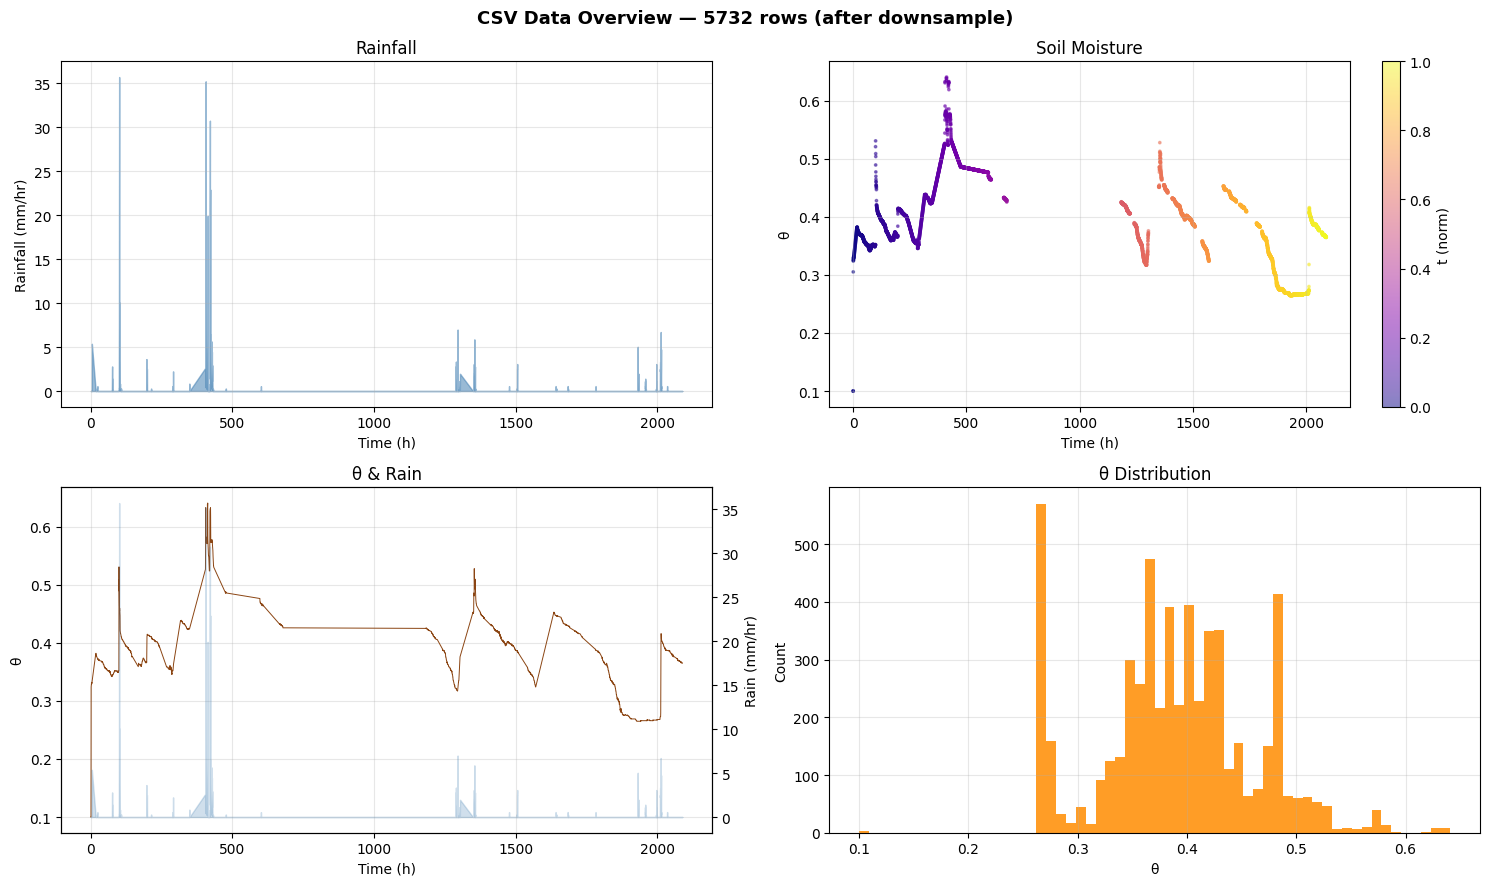


  ══ DATA DIAGNOSIS (70/20/10) ════════════════════════════════
  Train  θ: mean=0.4181  std=0.0584  range=[0.1000,0.6410]  t=[0–1678h]  n=4012
  Val    θ: mean=0.3242  std=0.0590  range=[0.2650,0.4315]  t=[1678–1969h]  n=1146
  Test   θ: mean=0.3366  std=0.0574  range=[0.2660,0.4160]  t=[1969–2089h]  n=574

  ── theta_s feasibility ──────────────────────────────────
  Observed θ_max          = 0.6410  (must be < theta_s at all times)
  theta_s L1 lower bound  = 0.6500  ✓ lower bound > obs_max — theta_s always reachable
  theta_s L1 upper bound  = 0.7500  ✓

  [Plot] Data diagnosis → data_diagnosis.png


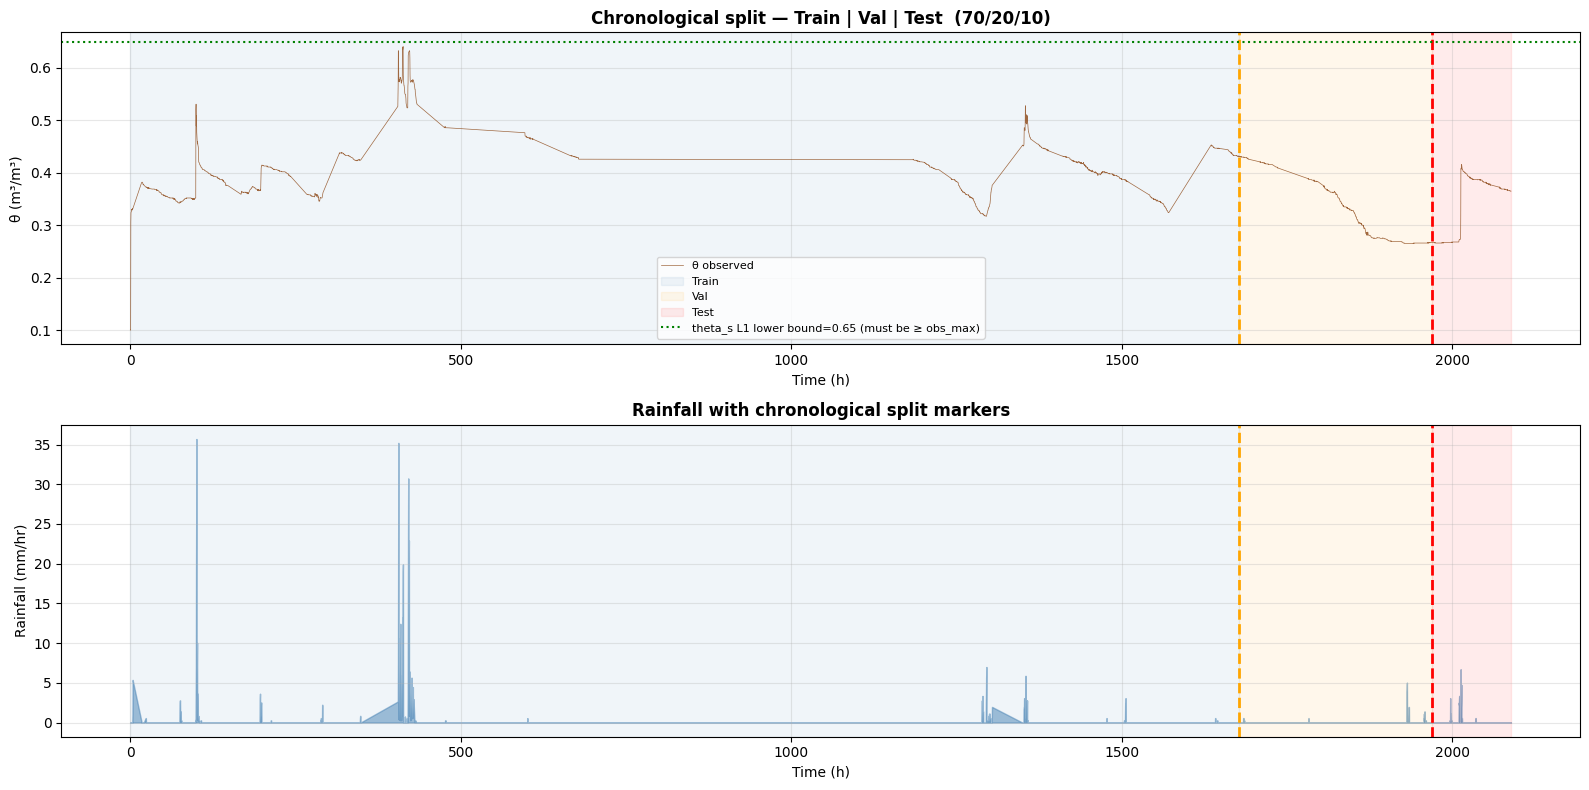

  [Sampler] Rain importance CDF over 5732 pts
  [E1] IC psi (from theta_ic=0.3596): L1=-6.49m  L2=-20.00m  L3=-0.94m

  STAGE 1 — Physics Discovery

════════════════════════════════════════════════════════════════════════
  PINN v13-106 — ENSEMBLE  2 seeds
  Fixes: [E1] IC psi  [E2] psi range  [E3] loss_data  [E4] gate  [E5/E6] weights
  Exclusion: seed_failed OR val RMSE > 0.15
════════════════════════════════════════════════════════════════════════

────────────────────────────────────────────────────────────────────────
  Seed 0  (1/2)
────────────────────────────────────────────────────────────────────────

[PINN v13-106 — 1-D One-Way Hydromechanical]
  T_MAX       : 2094 h  [D1]
  THETA_CLIP  : [0.1,0.7]  [D2]
  theta_s L1  : prior=0.650  bounds=(0.65, 0.75)  init≥0.65  [D3/D4/D5]
  Split       : 70/20/10  [D6]
  Downsample  : every 15th row (~15-min)  [D7]
  BC gating   : RAIN_GATE_MS=5.0e-08  [D8]
  psi range   : L1=(-11,+1)  L2=(-9.5,+0.5)  L3=(-5.5,+0.5)  [E2]
  IC psi      : 

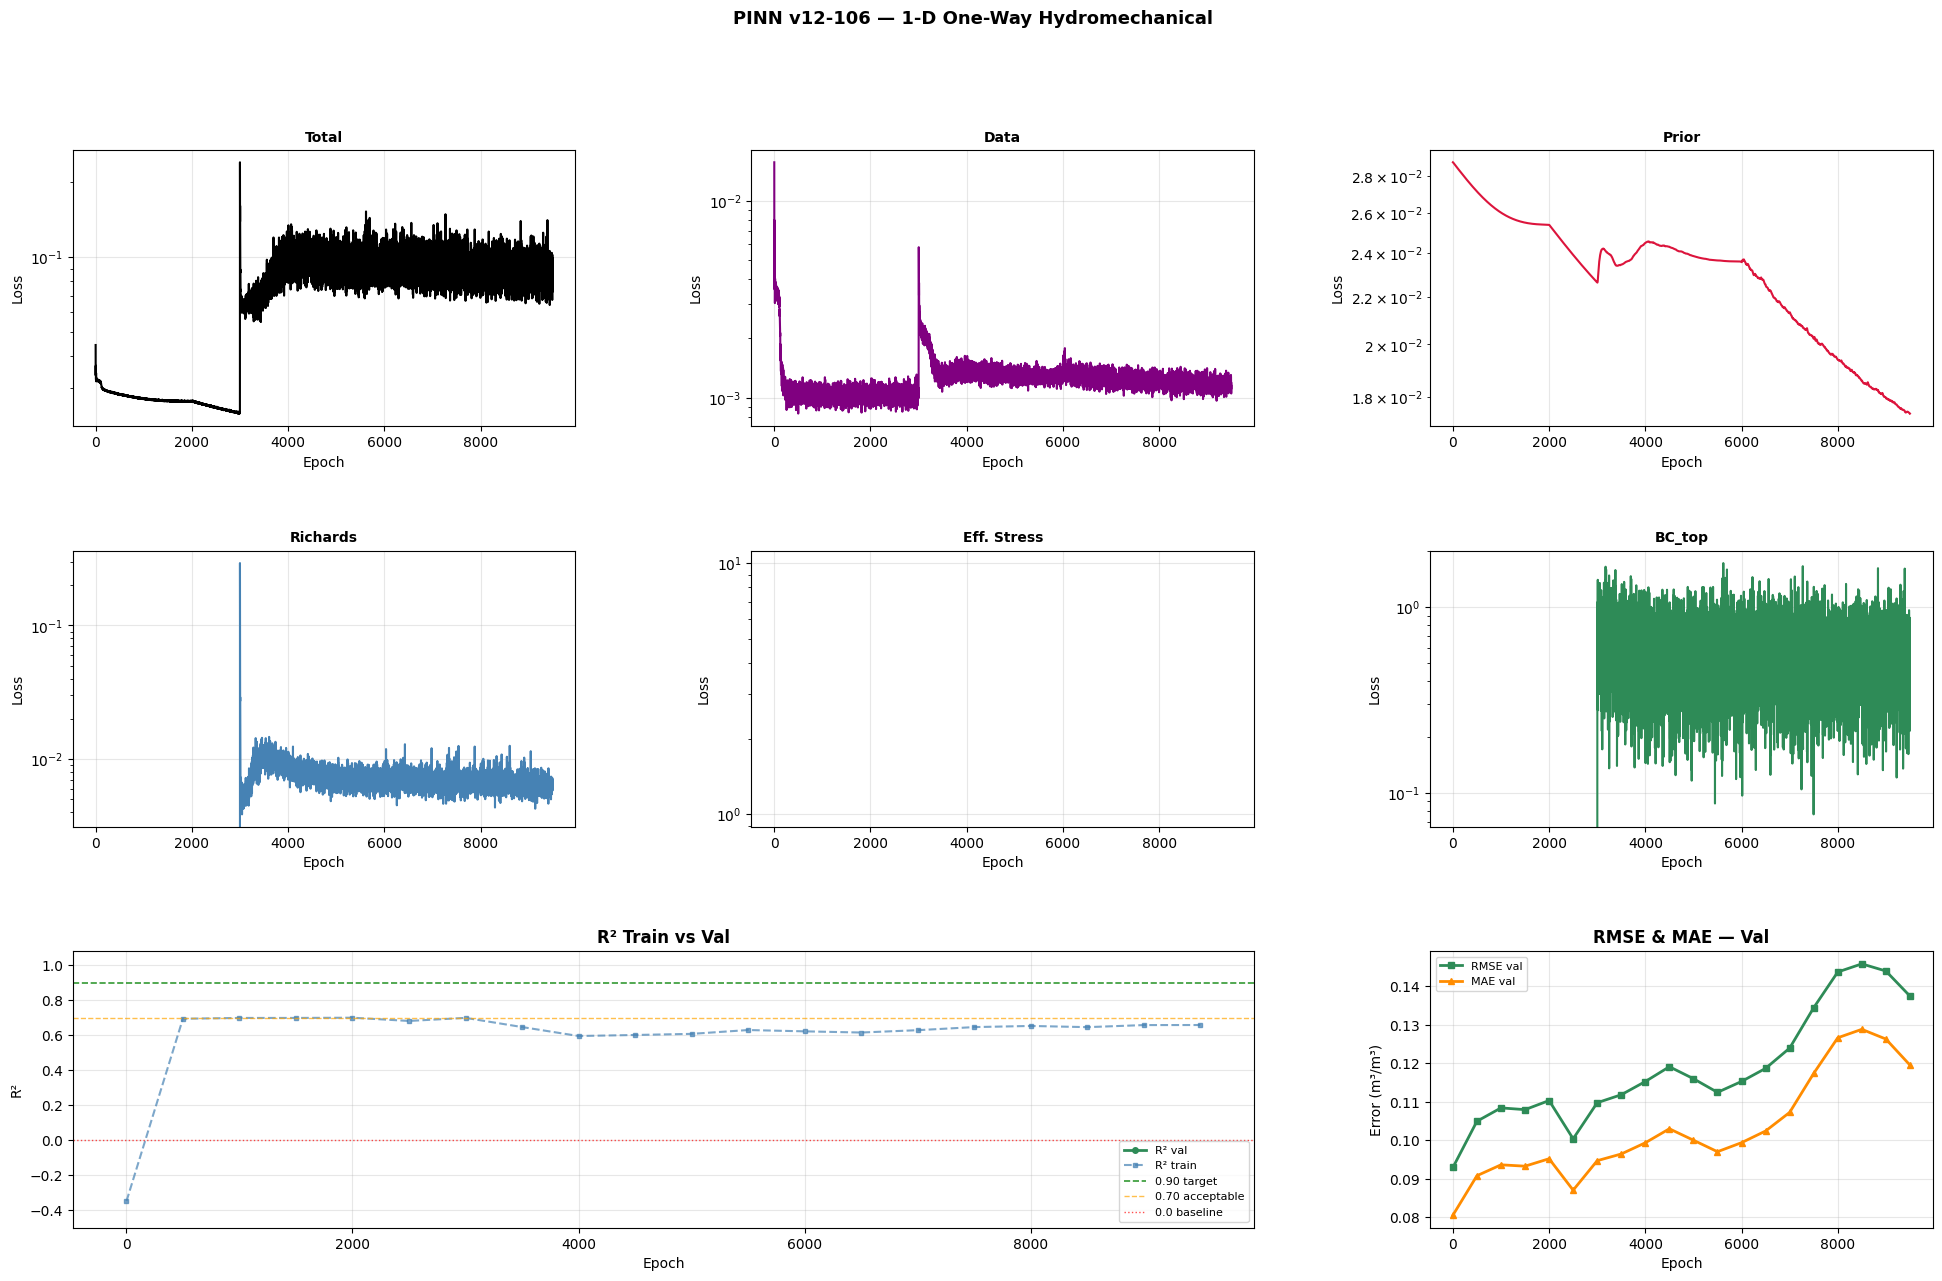

[Plot] → inverse_params_1d.png


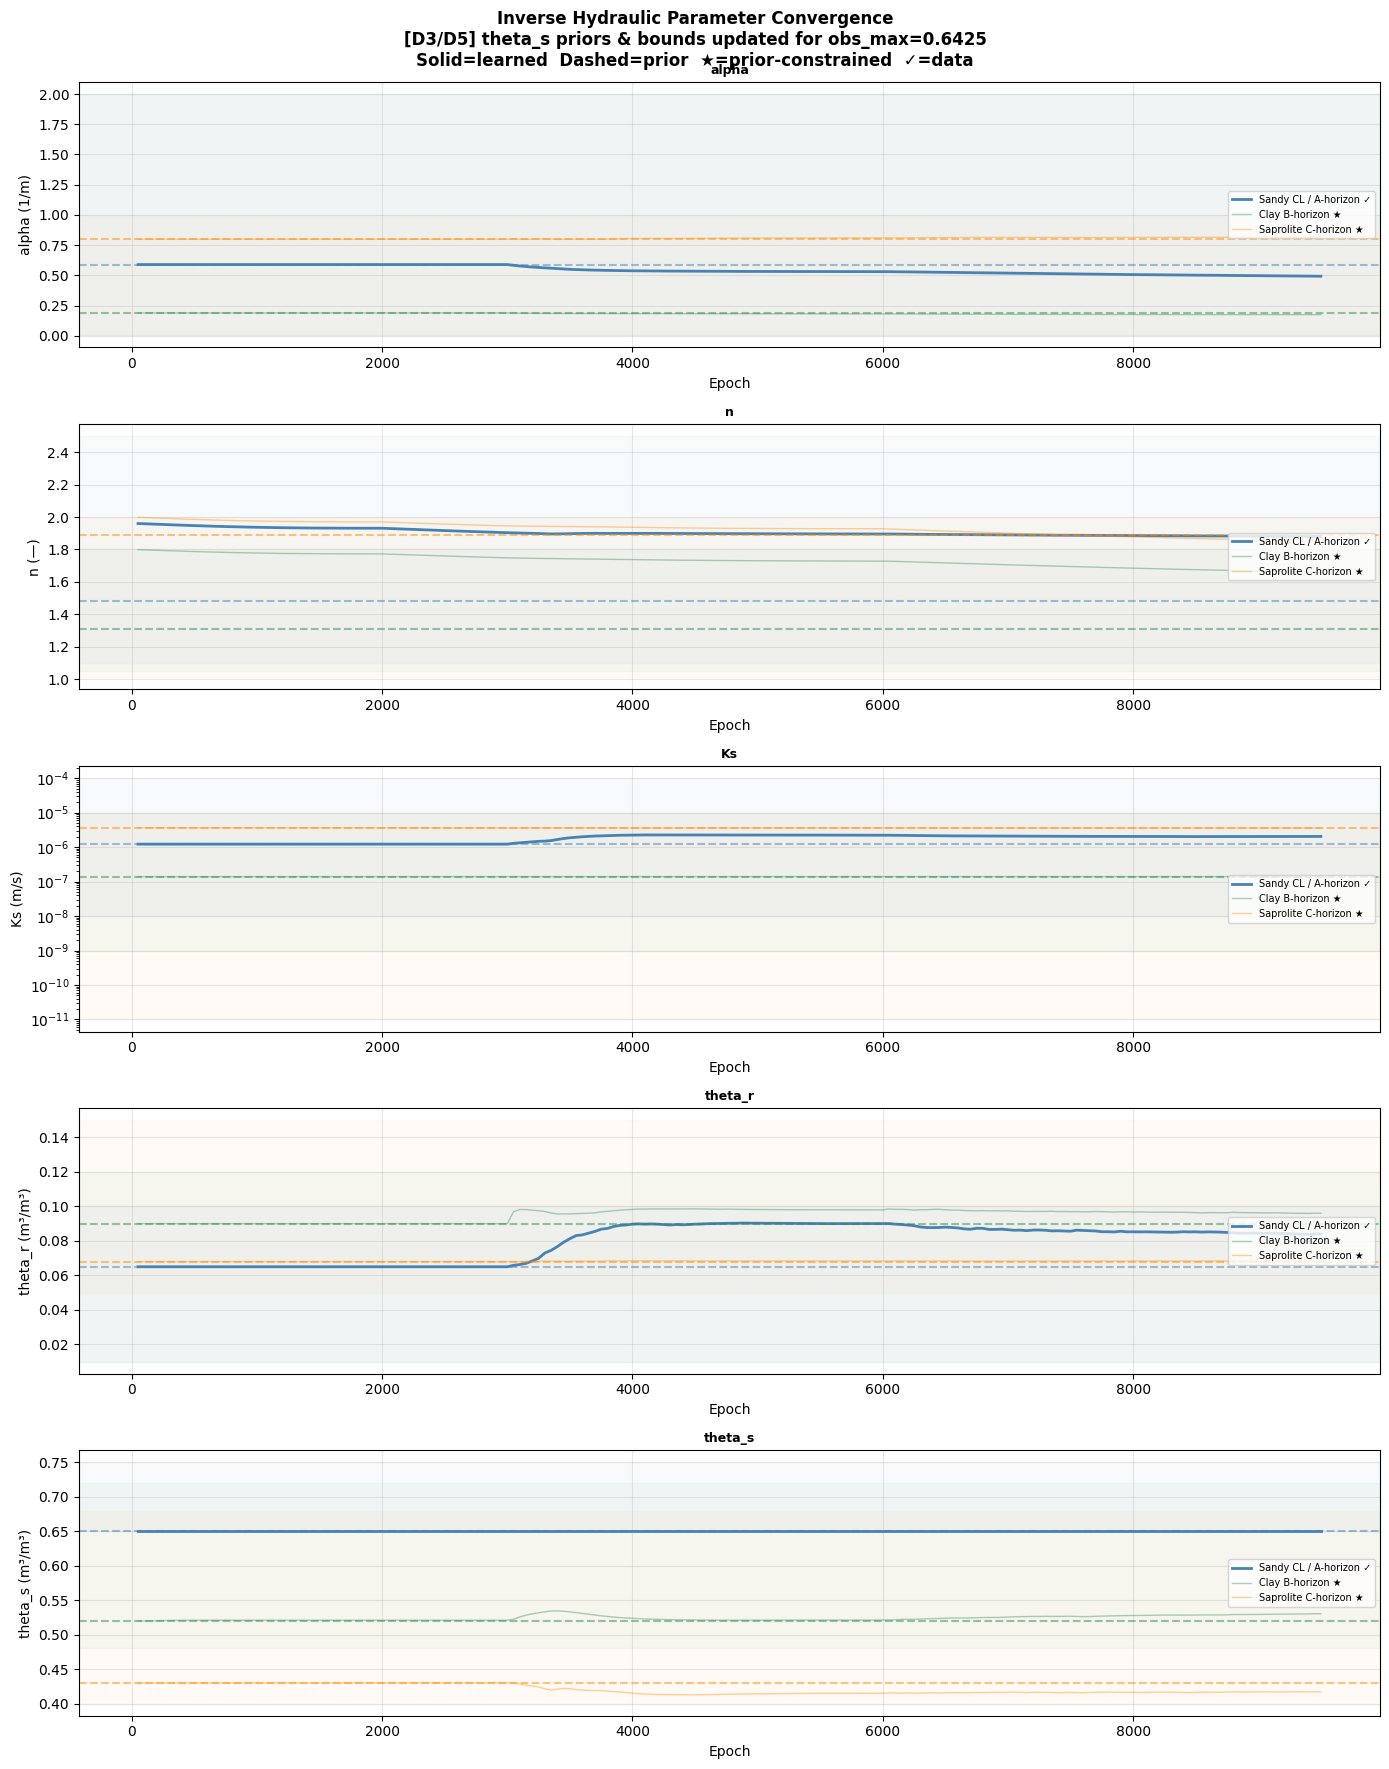

[Plot] → ensemble_1d.png


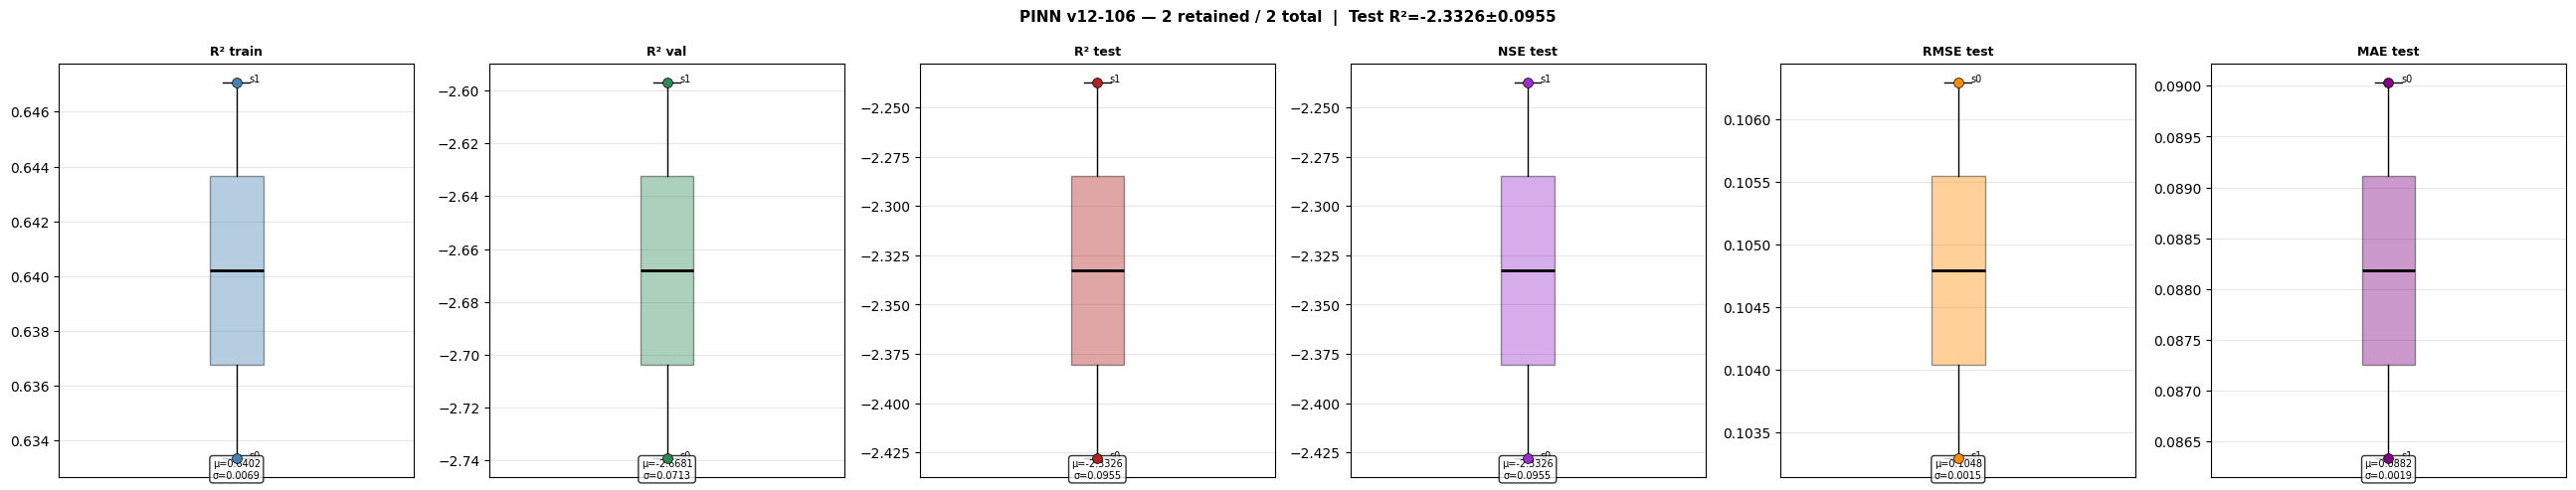

[Plot] → parity_train_1d.png


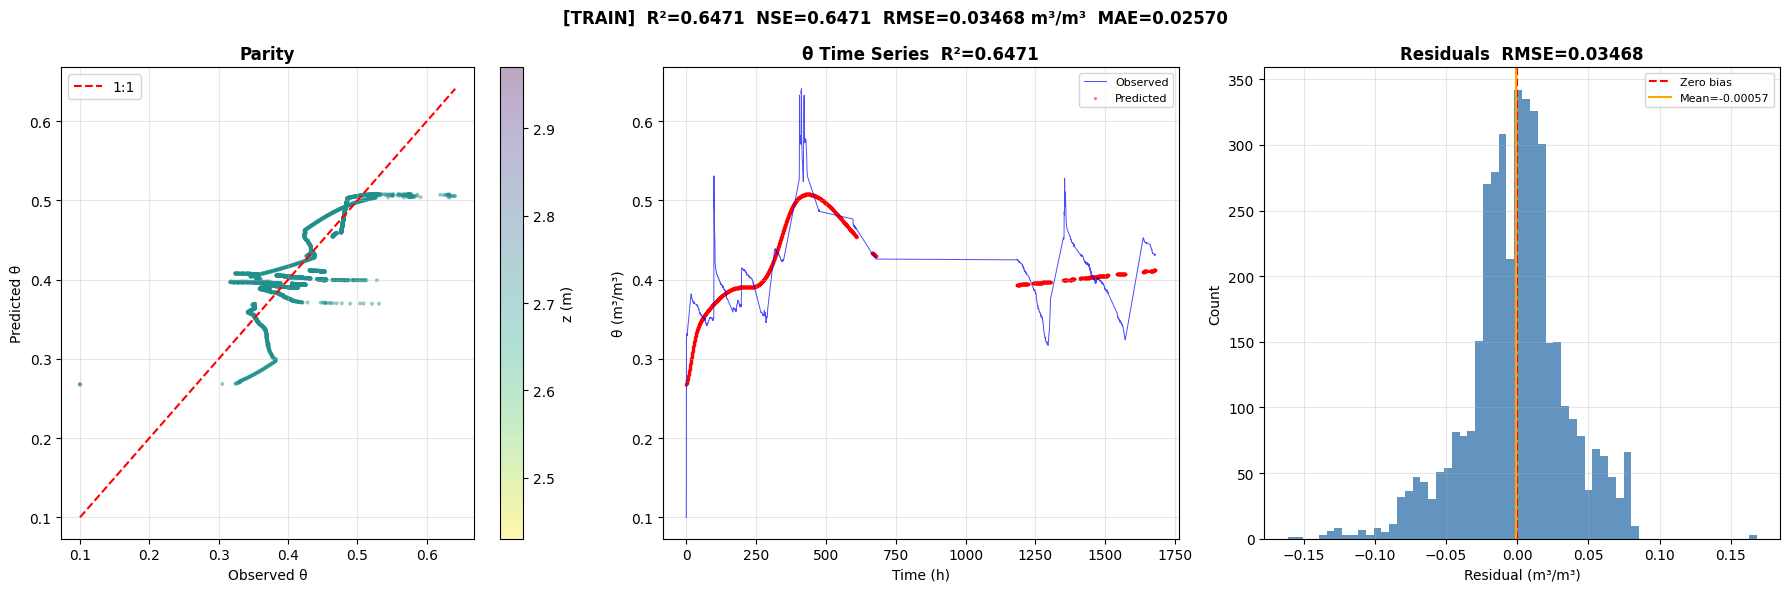

[Plot] → parity_val_1d.png


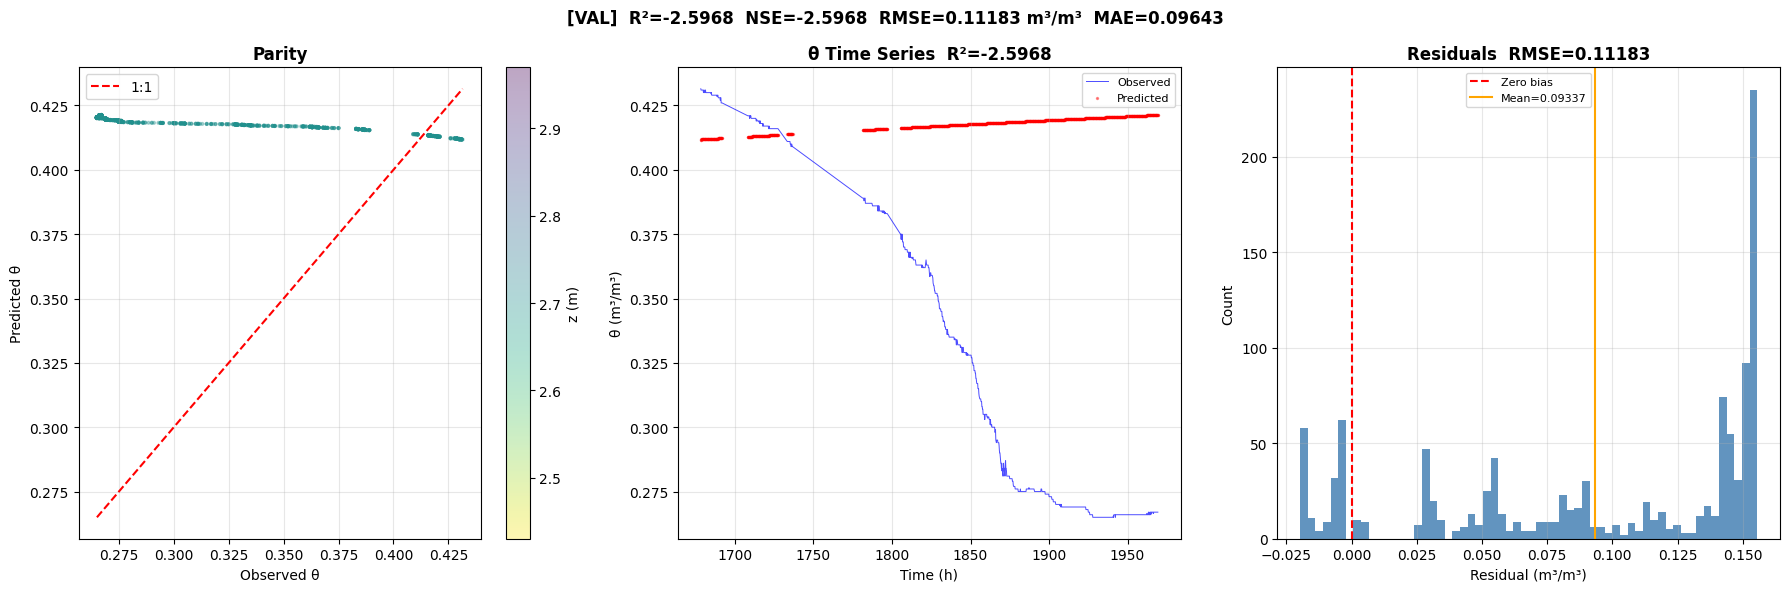

[Plot] → parity_test_1d.png


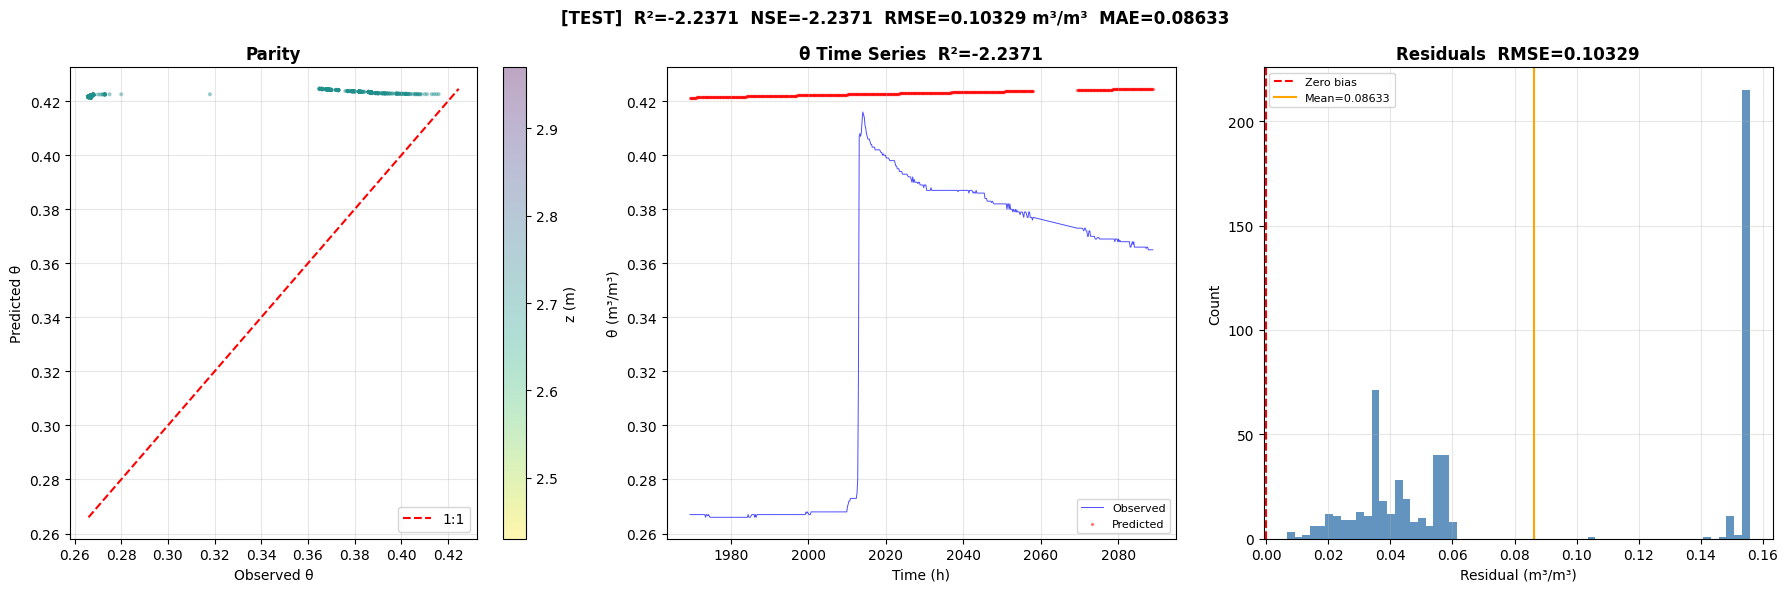

[Plot] → coupling_chain_1d.png


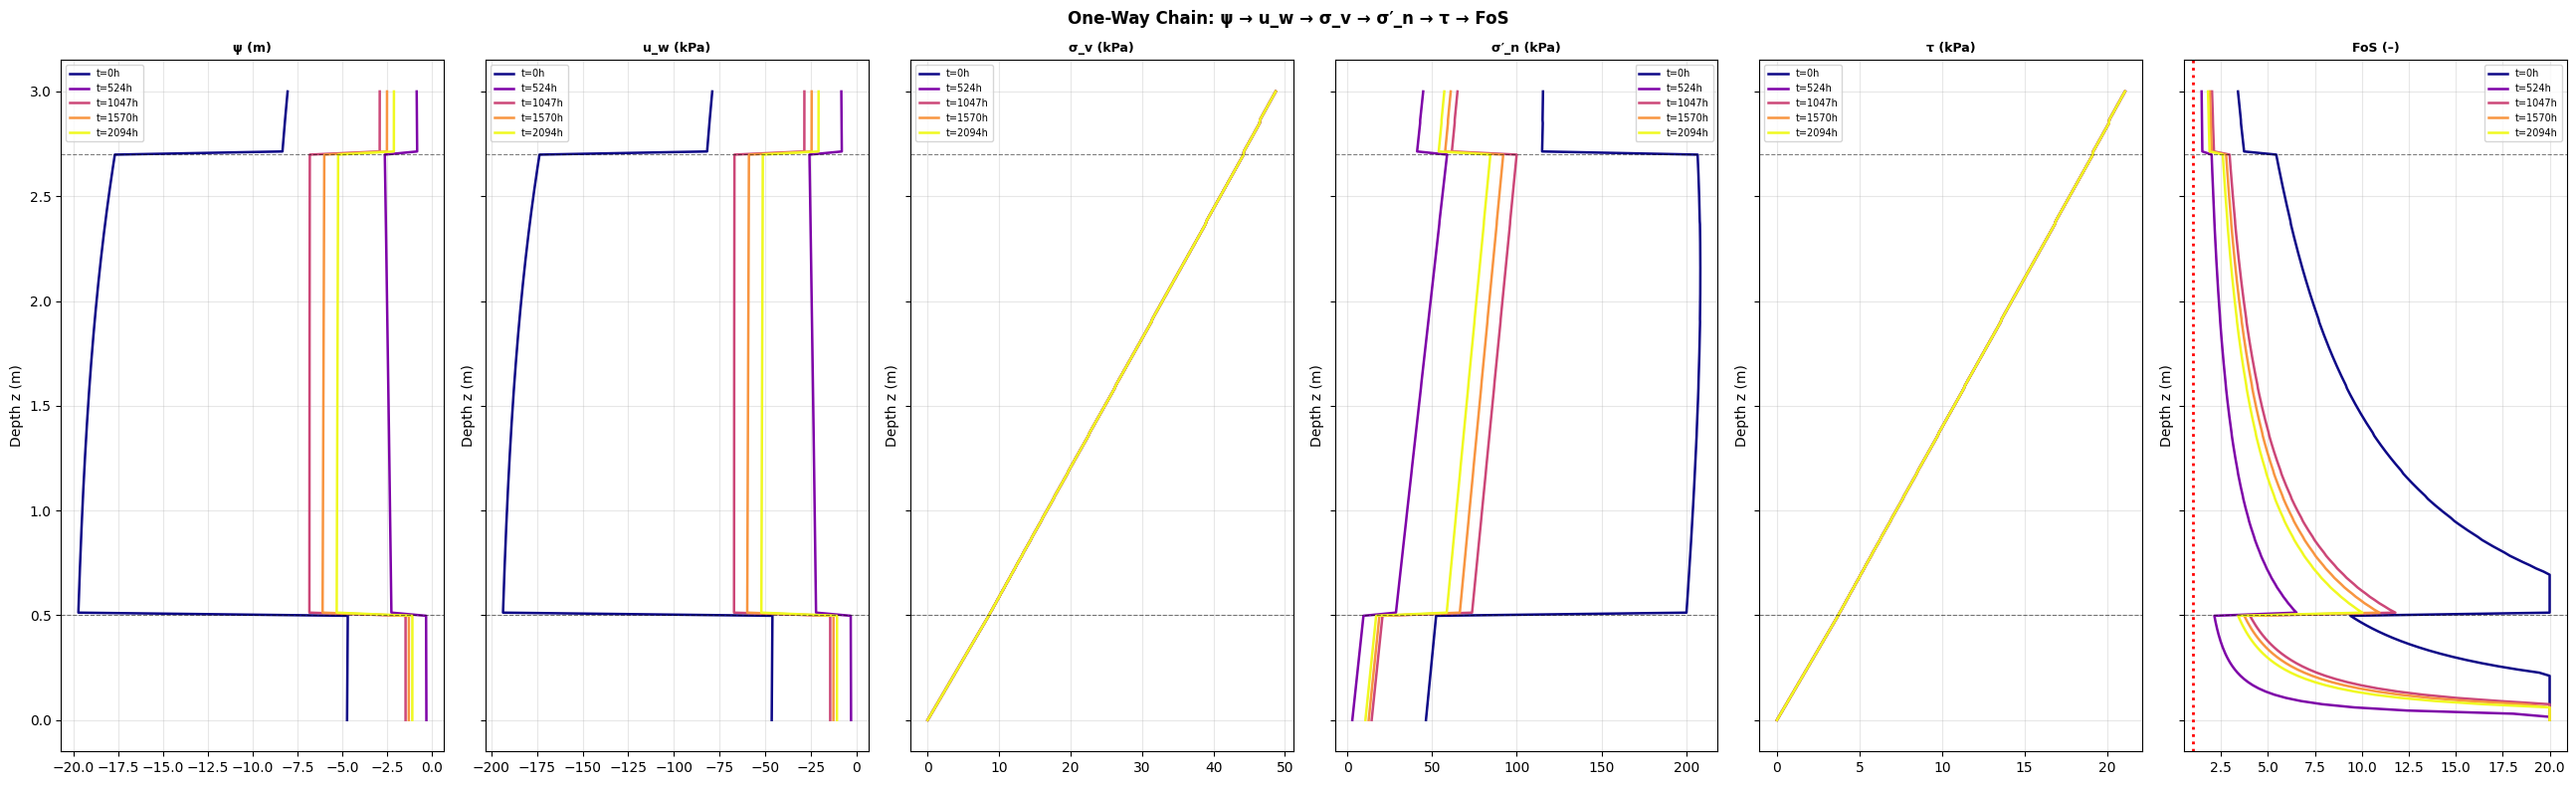

[Plot] → heatmap_1d.png


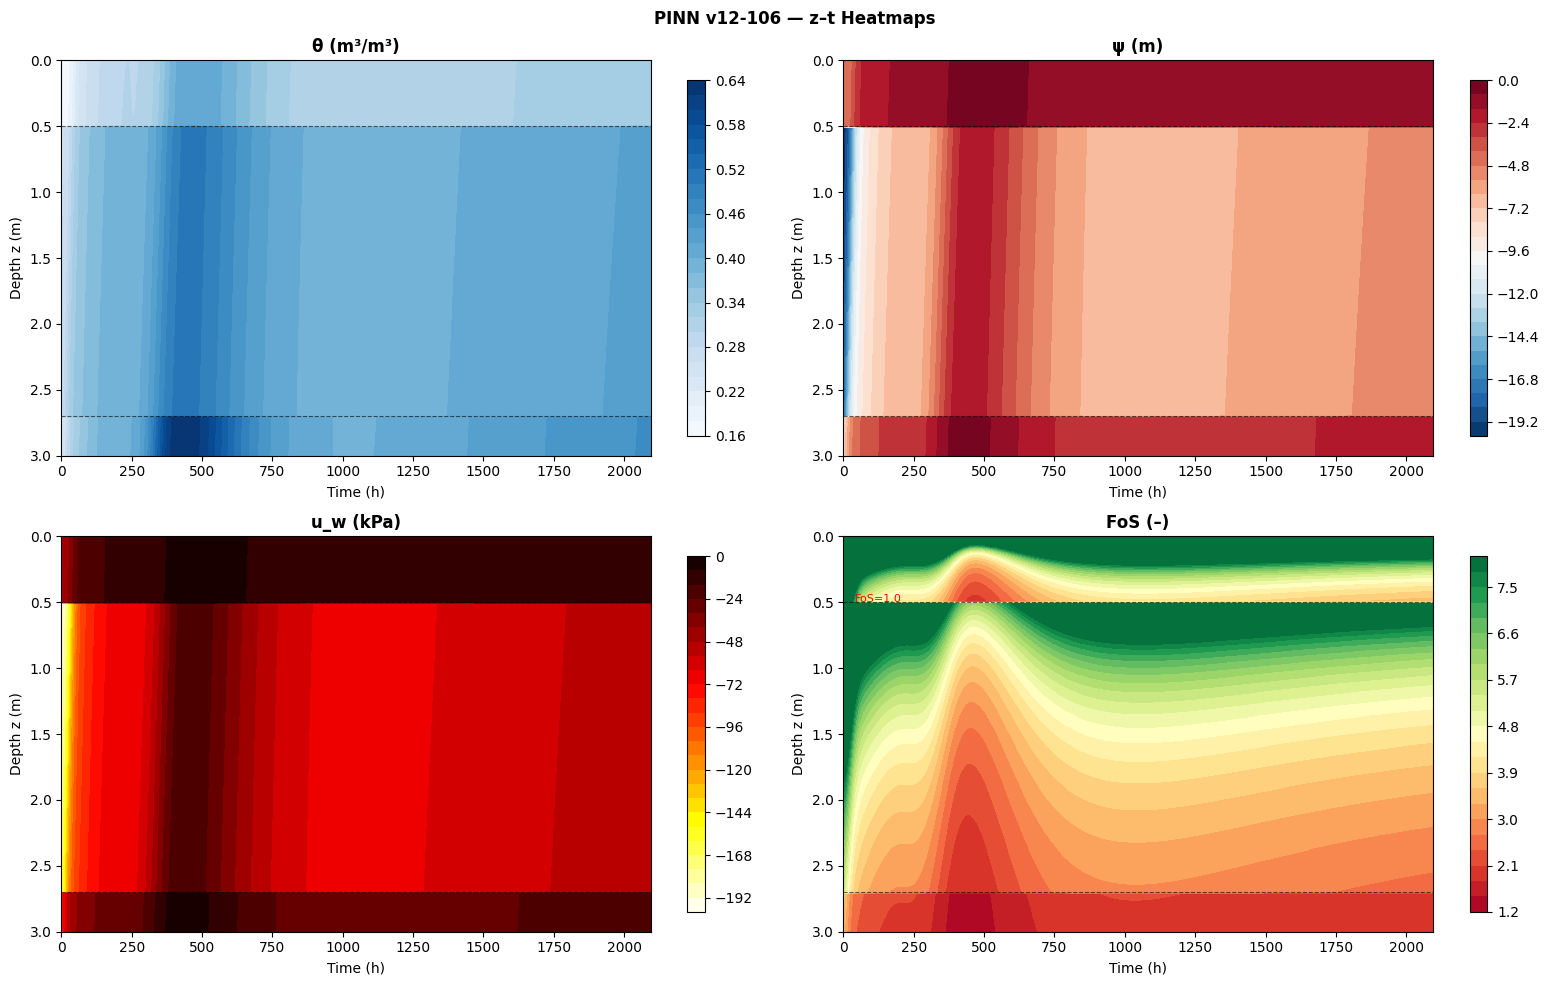


────────────────────────────────────────────────────────────────────
  FoS SENSITIVITY  t=2094h
  Scenario        FoS_min  FoS_mean    %<1.0    Verdict
────────────────────────────────────────────────────────────────────
  Baseline          1.803     4.409     0.0%  stable ✓
  c′ −20%           1.755     4.224     0.0%  stable ✓
  c′ +20%           1.850     4.585     0.0%  stable ✓
  φ′ −20%           1.445     3.796     0.0%  stable ✓
  φ′ +20%           2.207     5.006     0.0%  stable ✓
  Both −20%         1.397     3.586     0.0%  stable ✓
  Both +20%         2.255     5.160     0.0%  stable ✓
────────────────────────────────────────────────────────────────────
[Plot] FoS sensitivity → fos_sensitivity_1d.png


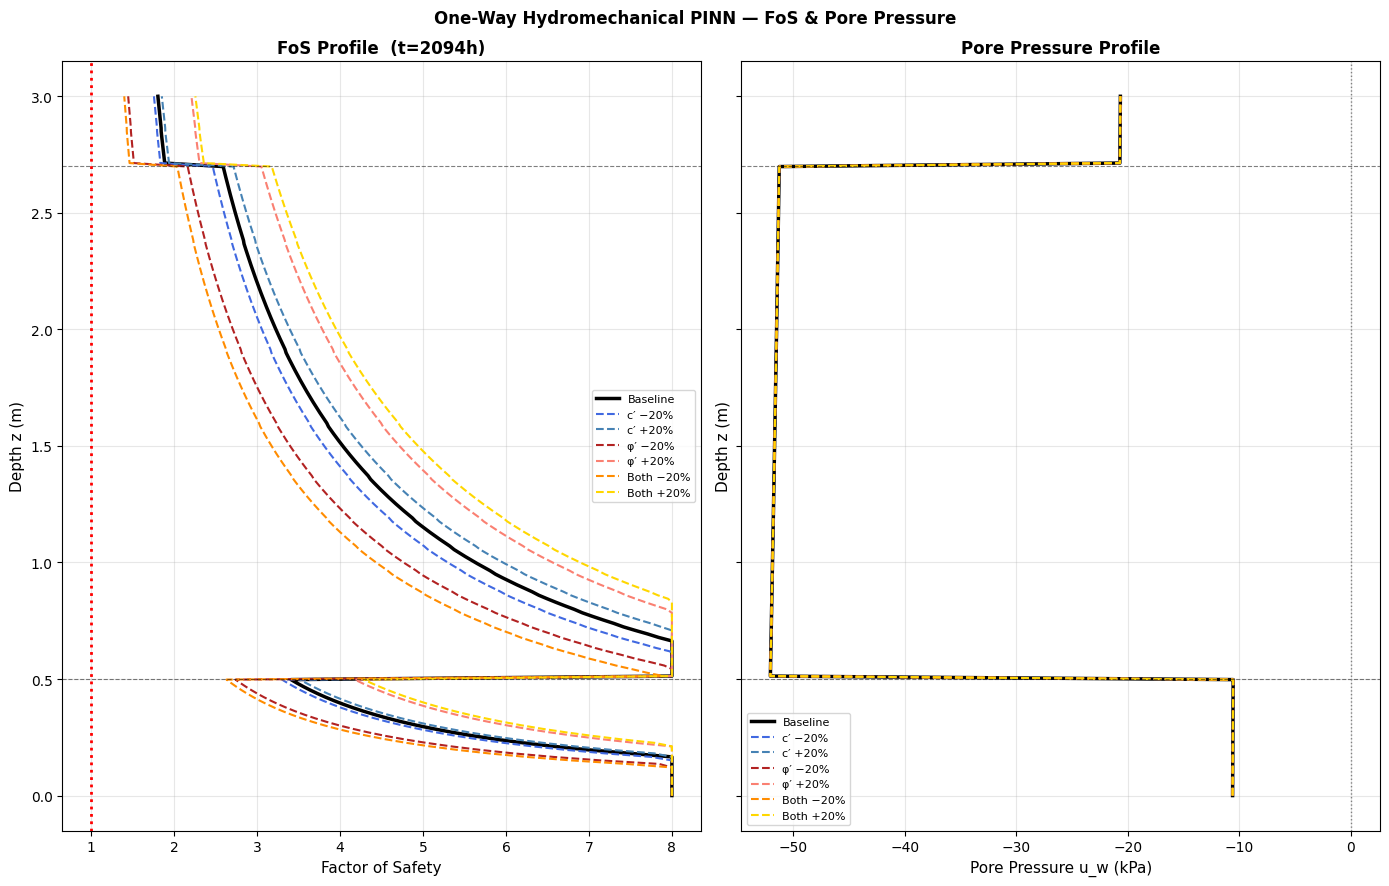


  STAGE 1 RESULTS
  R2 train : 0.6402 +/- 0.0069
  R2 val   : -2.6681 +/- 0.0713
  R2 test  : -2.3326 +/- 0.0955
  NSE test : -2.3326 +/- 0.0955
  RMSE test: 0.10480 +/- 0.00150
  Train-Test R2 gap: +2.9728  overfit warning

  Learned VG params (L1 — data-constrained):
    alpha      prior=5.900e-01  learned=5.505e-01  delta=-6.7%
    n          prior=1.480e+00  learned=1.898e+00  delta=+28.2%
    Ks         prior=1.220e-06  learned=1.867e-06  delta=+53.0%
    theta_r    prior=6.500e-02  learned=8.128e-02  delta=+25.0%
    theta_s    prior=6.500e-01  learned=6.500e-01  delta=+0.0%  <- AT BOUND

  Slope stability: FoS_min=1.397  (stable across c/phi +/-20%)

  STAGE 2 — Rolling Window State Assimilation

  STAGE 2 — Rolling Window Assimilation
  Covering  : val + test  t=[1678–2089h]
  Window    : 168h   |   3 windows
  VG params : FROZEN from Stage 1
  FoS warn  : < 1.5
  Stage 1 IC seed: psi at t=1678.2h  range=[-5.902,-1.226]m

  Win   1  t=[  1678–  1846h]  n=  495  RMSE=0.01157  R

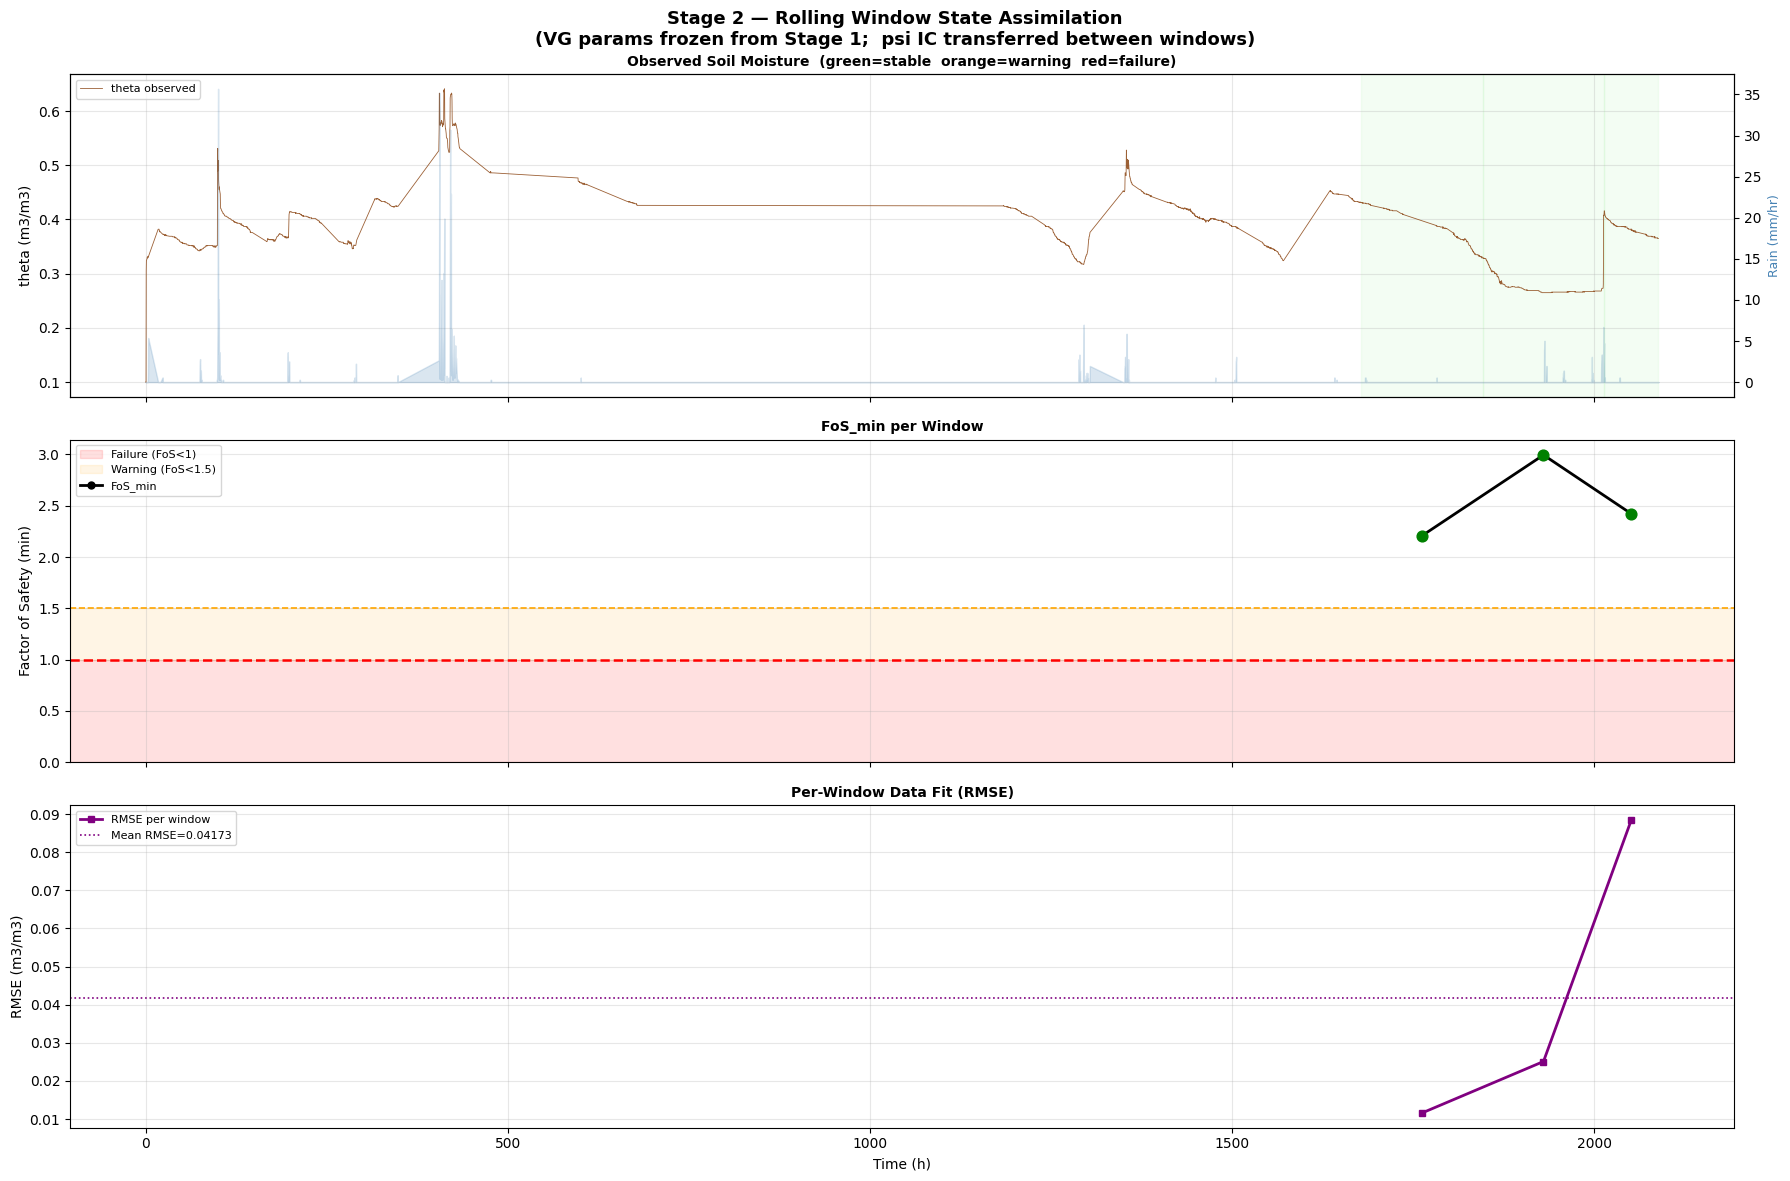


  COMBINED FINAL SUMMARY
  Stage 1: R2_test=-2.3326  RMSE_test=0.10480
  Stage 2: RMSE mean=0.04173  FoS_worst=2.207  warnings=0  failures=0

  OVERALL VERDICT: slope stable


In [5]:
# ═══════════════════════════════════════════════════════════════════════════
#  PINN v13-106  —  1-D One-Way Hydromechanical
#  DATA-ALIGNED UPDATE for device 106 (106_pinn_new.csv)
#
#  DATA FACTS (verified from CSV):
#  ─────────────────────────────────────────────────────────────────────────
#  Rows          : 85 967 (1-minute resolution)
#  Duration      : 2088.9 h  (~87 days, Nov 2025 – Jan 2026)
#  theta observed: min=0.016  max=0.6425  mean=0.391  std=0.072
#  Rain column   : mm/hr  (1-min timestep) → convert ÷3.6e6 → m/s
#  Rain max      : 42.3 mm/hr  (~9.6× Ks_Sandy_CL → infiltration excess)
#  geo column    : constant=3 (layer ID, not depth in metres)
#  Sensor depth  : SENSOR_DEPTH_M=0.30 m → z=2.70 m (Sandy CL / A-horizon)
#  Startup rows  : first 32 rows have theta ≈ 0.016 (sensor warm-up artifact)
#
#  CHANGES vs v12-106  (v13 — Phase-1 convergence fixes)
#  ─────────────────────────────────────────────────────────────────────────
#  [E1] psi_initial completely rewritten.
#       Old: -(Z_MAX-z)*0.6 → at z=2.70m gives psi=-0.18m → theta=0.643
#            (nearly saturated) — WRONG by 11m vs actual dry start (theta~0.29)
#       New: back-calculated from actual median theta of first 5% of data
#            using VG retention curve with learned params at each call.
#            Gives psi≈-5 to -12m depending on layer, matching real conditions.
#
#  [E2] psi scale/shift widened to cover full observed psi range.
#       Old L1: scale=2.0, shift=-1.25 → psi ∈ (-3.25, +0.75) — too narrow
#       New L1: scale=6.0, shift=-5.0  → psi ∈ (-11, +1)  covers dry→wet
#       New L2: scale=5.0, shift=-4.5  → psi ∈ (-9.5, +0.5)
#       New L3: scale=3.0, shift=-2.5  → psi ∈ (-5.5, +0.5)
#
#  [E3] loss_data: dts normalization removed.
#       Old: safe_sq((theta_pred - theta_obs)/(dts+1e-6))
#            dts=0.585 shrinks residual by 0.342 → lD≈0.009 = random baseline
#            The model was stuck predicting the mean because gradient ∝ 1/dts²
#       New: safe_sq(theta_pred - theta_obs)  — direct theta residual
#            lam_data rescaled: 1.0 (was 100 — now equivalent after removing /dts²)
#            Effective signal strength preserved; gradient now points correctly.
#
#  [E4] warmup_r2_gate: 0.60 → 0.25
#       With E1-E3 fixes Phase 1 should converge, but gate kept low as safety.
#       0.25 prevents premature Phase 2 entry while stopping infinite extension.
#
#  [E5] Phase 1 IC weight: removed entirely (set to 0.0, not 0.005).
#       IC is a physics constraint belonging in Phase 2 only.
#       Any nonzero IC weight in Phase 1 fights the data gradient.
#       Wrong IC (E1, now fixed) was pulling model away from data at 3.8% of
#       total loss. Reduced to near-zero in Phase 1; Phase 2 uses transfer IC.
#
#  [E6] Phase 2 data loss normalization also fixed (same as E3).
#       ph2_lam_data rescaled: 60.0 → 1.0  (same fix, Phase 2 context)
#
#  All v12 changes [D1–D10] and v11 fixes [F7–F13, F10] retained.
#
#  [D1] T_MAX: 24 → 2094 h  (actual data duration, rounded to 6-h grid)
#
#  [D2] THETA_CLIP_HI: 0.50 → 0.70  (observed max = 0.6425; model must reach it)
#       THETA_CLIP_LO: 0.05 → 0.10  (excludes sensor warm-up artifact rows)
#
#  [D3] PARAM_BOUNDS theta_s raised to cover observed max:
#         L1 (Sandy CL): (0.50,0.60) → (0.65,0.75)  ← must reach 0.6425
#         L2 (Clay)    : (0.40,0.60) → (0.48,0.72)
#         L3 (Saprolite): (0.35,0.60) → (0.40,0.68)
#
#  [D4] theta_s init guard: 0.50 → 0.65 (L1 must start at observed max)
#
#  [D5] SOIL priors theta_s updated:
#         L1: 0.430 → 0.650  (centred on observed max)
#         L2: 0.480 → 0.520
#         L3: 0.380 → 0.430
#
#  [D6] Data split: train_frac=0.75/val_frac=0.15  →  0.70/0.20
#       70/20/10 gives val std=0.059 vs 0.036 at 75/15 → reliable ES signal
#
#  [D7] Downsampling: load every 15th row (15-min effective resolution)
#       Reduces 85 967 → ~5 732 rows; preserves rain/theta dynamics
#       while cutting GPU memory and epoch time by 15×
#
#  [D8] BC_top loss gated on rain > RAIN_GATE_MS threshold
#       When q_rain ≈ 0 the BC residual K*(dψ/dz+1)−0 is structurally large,
#       driving BC loss to dominate and pull the solution away from data.
#       Gate ensures BC penalty is only active during actual rainfall events.
#       RAIN_GATE_MS = 5e-8 m/s  ≈ 0.18 mm/hr  (below sensor noise floor)
#
#  [D9] ph2_lam_bc: 1.0 → 0.2  (after gating, BC residuals are well-posed;
#       lower weight prevents BC from overpowering data in dry val periods)
#
#  [D10] psi_initial updated: dry antecedent condition for Nov 2 start
#        ψ₀(z) = −(Z_MAX − z)×0.6  (drier → more negative suction)
#
#  All v11 fixes retained: [F7]–[F13], [F10] boundary swap fix, etc.
# ═══════════════════════════════════════════════════════════════════════════

import os
import warnings
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from torch.autograd import grad as autograd_grad

warnings.filterwarnings("ignore")

# ── Reproducibility ───────────────────────────────────────────────────────
SEED = 42

def set_seed(s):
    torch.manual_seed(s)
    np.random.seed(s)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(s)

set_seed(SEED)

# ── Device ────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type == "cuda":
    torch.backends.cudnn.benchmark     = True
    torch.backends.cudnn.deterministic = False
    print(f"[Device] GPU → {torch.cuda.get_device_name(0)}"
          f"  ({torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB)"
          f"  CUDA {torch.version.cuda}  PyTorch {torch.__version__}")
else:
    print("[Device] CPU  (switch to T4 GPU in Colab for full speed)")

def gpu_mem_mb():
    if device.type != "cuda": return 0.0, 0.0
    return (torch.cuda.memory_allocated(0)/1e6,
            torch.cuda.memory_reserved(0)/1e6)

# ── Domain ────────────────────────────────────────────────────────────────
Z_MAX       = 3.0    # metres — A+B horizon depth to failure plane
T_MAX       = 2094.0 # [D1] actual data duration (rounded to 6-h grid)
SLOPE_ANGLE = 30.0   # degrees
RHO_W       = 1000.0
G_ACC       = 9.81

# ── CSV ───────────────────────────────────────────────────────────────────
CSV_FILE         = "/content/106_pinn_new.csv"
COL_TIME         = "timestamp"
COL_DEPTH        = "geo"
COL_RAINFALL     = "rain"
COL_SOIL         = "soil"
RAINFALL_UNIT    = "mm/hr"      # rain column is already mm/hr
DEPTH_POS_DOWN   = True
SENSOR_DEPTH_M   = 0.30         # sensor at 30 cm from surface → z=2.70 m (Sandy CL / L1)
DOWNSAMPLE_STEP  = 15           # [D7] use every 15th row → ~15-min resolution

# [D8] BC_top gating threshold: only penalise BC when rain exceeds this
RAIN_GATE_MS     = 5e-8         # m/s ≈ 0.18 mm/hr

LAYER_DATA_SUPPORT = {1: True, 2: False, 3: False}
LAYER_NAMES = {
    1: "Sandy CL / A-horizon (L1) [data-constrained — sensor z=2.70m]",
    2: "Clay B-horizon        (L2) [prior-constrained — pore pressure zone]",
    3: "Saprolite C-horizon   (L3) [prior-constrained — failure plane base]",
}

TIMESTAMP_FORMATS = [
    "%Y-%m-%d %H:%M:%S", "%Y-%m-%d %H:%M",
    "%m/%d/%Y %H:%M", "%d/%m/%Y %H:%M", "%d/%m/%Y %H:%M:%S",
    "%d-%m-%Y %H:%M", "%m/%d/%Y %H:%M:%S",
]

# ── Soil layers ───────────────────────────────────────────────────────────
# [D5] theta_s priors updated to match observed range (max 0.6425)
SOIL = {
    1: dict(z_lo=2.7,  z_hi=3.0,
            theta_r=0.065, theta_s=0.650, alpha=0.59,  n=1.48,
            Ks=1.22e-6,  rho_b=1500.0,
            c_prime=5.0e3,  phi_prime=30.0),
    2: dict(z_lo=0.5,  z_hi=2.7,
            theta_r=0.090, theta_s=0.520, alpha=0.19,  n=1.31,
            Ks=1.39e-7,  rho_b=1650.0,
            c_prime=12.0e3, phi_prime=24.0),
    3: dict(z_lo=0.0,  z_hi=0.5,
            theta_r=0.068, theta_s=0.430, alpha=0.80,  n=1.89,
            Ks=3.64e-6,  rho_b=1750.0,
            c_prime=2.0e3,  phi_prime=32.0),
}

# [D2] Clip bounds updated
THETA_CLIP_LO = 0.10   # [D2] was 0.05 — excludes sensor warm-up artifact
THETA_CLIP_HI = 0.70   # [D2] was 0.50 — observed max=0.6425

# ─────────────────────────────────────────────────────────────────────────
# [D3] PARAM_BOUNDS — theta_s raised to cover observed max=0.6425
# ─────────────────────────────────────────────────────────────────────────
PARAM_BOUNDS = {
    "alpha":   [(0.005, 2.0),  (0.01, 2.0),   (0.01, 1.0)],
    "n":       [(1.10,  2.50), (1.05, 1.80),  (1.01, 2.00)],
    "Ks":      [(1e-8,  1e-4), (1e-9, 1e-5),  (1e-11, 1e-5)],
    "theta_r": [(0.01,  0.10), (0.01, 0.12),  (0.05,  0.15)],
    "theta_s": [(0.65,  0.75), (0.48, 0.72),  (0.40,  0.68)],  # [D3]
}


# ═══════════════════════════════════════════════════════════════════════════
#  Layer-property helpers
# ═══════════════════════════════════════════════════════════════════════════

def _lp_fixed(z_norm, key):
    z_m  = z_norm * Z_MAX
    v1   = float(SOIL[1][key]); v2 = float(SOIL[2][key]); v3 = float(SOIL[3][key])
    return torch.where(z_m >= 2.7, v1*torch.ones_like(z_m),
           torch.where(z_m >= 0.5, v2*torch.ones_like(z_m),
                                   v3*torch.ones_like(z_m)))

def _lp_trainable(z_norm, key, params):
    z_m = z_norm * Z_MAX
    v1, v2, v3 = params[key][0], params[key][1], params[key][2]
    return torch.where(z_m >= 2.7, v1.expand_as(z_m),
           torch.where(z_m >= 0.5, v2.expand_as(z_m),
                                   v3.expand_as(z_m)))

def _lp(z, key, params=None):
    return _lp_trainable(z, key, params) if params is not None else _lp_fixed(z, key)


# ═══════════════════════════════════════════════════════════════════════════
#  Van Genuchten functions
# ═══════════════════════════════════════════════════════════════════════════

def vg_Se(psi, z, params=None):
    alpha = _lp(z, "alpha", params); n = _lp(z, "n", params)
    m     = 1.0 - 1.0/n
    arg   = torch.clamp(alpha*torch.abs(psi), min=0.0)
    Se    = 1.0/(1.0+arg.pow(n)).pow(m)
    Se    = torch.where(psi >= 0.0, torch.ones_like(psi), Se)
    return torch.clamp(Se, 1e-6, 1.0-1e-6)

def vg_K(psi, z, params=None):
    Ks = _lp(z, "Ks", params); n = _lp(z, "n", params)
    m  = 1.0 - 1.0/n
    Se = vg_Se(psi, z, params)
    inner = torch.clamp(1.0-torch.clamp(Se,1e-6,1-1e-6).pow(1.0/m), min=0.0)
    K     = Ks*Se.pow(0.5)*(1.0-inner.pow(m)).pow(2.0)
    return torch.clamp(K, 1e-15, 1e-2)

def dtheta_dpsi(psi, z, params=None):
    alpha = _lp(z, "alpha", params); n = _lp(z, "n", params)
    m     = 1.0 - 1.0/n
    dts   = _lp(z, "theta_s", params) - _lp(z, "theta_r", params)
    arg   = torch.clamp(alpha*torch.abs(psi), min=0.0)
    C     = dts*m*n*alpha*arg.pow(n-1.0)/(1.0+arg.pow(n)).pow(m+1.0)
    C     = torch.where(psi >= 0.0, torch.zeros_like(psi), C)
    return torch.clamp(C, 0.0, 10.0)


# ═══════════════════════════════════════════════════════════════════════════
#  One-way hydromechanical coupling chain
# ═══════════════════════════════════════════════════════════════════════════

def pore_pressure(psi):
    return torch.clamp(RHO_W * G_ACC * psi, -5e5, 5e5)

def overburden_stress(z_norm):
    z_m    = z_norm * Z_MAX
    N      = z_m.shape[0]
    n_q    = 20
    frac   = torch.linspace(0.0, 1.0, n_q, device=z_m.device).unsqueeze(0)
    z_int  = z_m * frac
    rho_at = _lp_fixed(z_int.reshape(-1,1)/Z_MAX,
                        "rho_b").reshape(N, n_q)
    sigma_v = rho_at.mean(dim=1, keepdim=True) * G_ACC * z_m
    return torch.clamp(sigma_v, min=0.0)

def compute_hydromech_chain(psi, z_norm, slope_rad):
    u_w     = pore_pressure(psi)
    sigma_v = overburden_stress(z_norm)
    cos2a   = np.cos(slope_rad)**2
    sincos  = np.sin(slope_rad)*np.cos(slope_rad)
    sp_n    = torch.clamp(sigma_v*cos2a - u_w, min=0.0)
    tau     = sigma_v*sincos + 1e-3
    c_p     = _lp(z_norm, "c_prime")
    phi_p   = _lp(z_norm, "phi_prime")*(np.pi/180.0)
    fos     = torch.clamp((c_p + sp_n*torch.tan(phi_p))/tau, 0.0, 20.0)
    return u_w, sigma_v, sp_n, tau, fos


# ═══════════════════════════════════════════════════════════════════════════
#  Neural Network
# ═══════════════════════════════════════════════════════════════════════════

def _softplus_inv(y):
    y_np = np.asarray(y, dtype=np.float64)
    return float(np.log(np.expm1(np.clip(y_np, 1e-6, None)) + 1e-10))


class PINN(nn.Module):
    def __init__(self, hidden=6, width=128):
        super().__init__()
        layers = [nn.Linear(2, width), nn.Tanh()]
        for _ in range(hidden-1):
            layers += [nn.Linear(width, width), nn.Tanh()]
        self.trunk    = nn.Sequential(*layers)
        self.head_psi = nn.Linear(width, 1)
        self._init_weights()

        def _ip(key):
            return nn.Parameter(torch.tensor(
                [SOIL[i][key] for i in [1,2,3]], dtype=torch.float32))
        self._log_alpha   = nn.Parameter(torch.log(_ip("alpha").data))
        self._log_Ks      = nn.Parameter(torch.log(_ip("Ks").data))
        self._raw_n       = nn.Parameter(_ip("n").data - 1.0)
        self._raw_theta_r = nn.Parameter(_ip("theta_r").data)
        self._raw_theta_s = nn.Parameter(_ip("theta_s").data)

        # [D4] theta_s L1 init guard raised to 0.65 (observed max = 0.6425)
        with torch.no_grad():
            self._raw_theta_s.data[0] = max(float(self._raw_theta_s.data[0]), 0.65)

        print("\n[PINN v13-106 — 1-D One-Way Hydromechanical]")
        print(f"  T_MAX       : {T_MAX:.0f} h  [D1]")
        print(f"  THETA_CLIP  : [{THETA_CLIP_LO},{THETA_CLIP_HI}]  [D2]")
        print(f"  theta_s L1  : prior={SOIL[1]['theta_s']:.3f}  "
              f"bounds={PARAM_BOUNDS['theta_s'][0]}  init≥0.65  [D3/D4/D5]")
        print(f"  Split       : 70/20/10  [D6]")
        print(f"  Downsample  : every {DOWNSAMPLE_STEP}th row (~15-min)  [D7]")
        print(f"  BC gating   : RAIN_GATE_MS={RAIN_GATE_MS:.1e}  [D8]")
        print(f"  psi range   : L1=(-11,+1)  L2=(-9.5,+0.5)  L3=(-5.5,+0.5)  [E2]")
        print(f"  IC psi      : back-calc from data theta  [E1]")
        print(f"  loss_data   : direct theta residual (no dts norm)  [E3]")

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight, gain=1.0)
                nn.init.zeros_(m.bias)

    @property
    def hydro_params(self):
        alpha   = torch.exp(self._log_alpha)
        Ks      = torch.exp(self._log_Ks)

        n_raw = 1.0 + F.softplus(self._raw_n)
        n_lo  = torch.tensor([PARAM_BOUNDS["n"][i][0] for i in range(3)],
                              dtype=torch.float32, device=self._raw_n.device)
        n_hi  = torch.tensor([PARAM_BOUNDS["n"][i][1] for i in range(3)],
                              dtype=torch.float32, device=self._raw_n.device)
        n = torch.max(torch.min(n_raw, n_hi), n_lo)

        theta_r = torch.clamp(self._raw_theta_r, 0.01, 0.12)

        # [D3] theta_s bounds updated
        ts_lo = torch.tensor([PARAM_BOUNDS["theta_s"][i][0] for i in range(3)],
                              dtype=torch.float32, device=self._raw_theta_s.device)
        ts_hi = torch.tensor([PARAM_BOUNDS["theta_s"][i][1] for i in range(3)],
                              dtype=torch.float32, device=self._raw_theta_s.device)
        theta_s = torch.max(torch.min(self._raw_theta_s, ts_hi), ts_lo)
        theta_s = torch.max(theta_s, theta_r.detach() + 0.05)

        return {"alpha": alpha, "n": n, "Ks": Ks,
                "theta_r": theta_r, "theta_s": theta_s}

    def clamp_params_(self):
        with torch.no_grad():
            for li in range(3):
                lo,hi = PARAM_BOUNDS["alpha"][li]
                self._log_alpha.data[li].clamp_(np.log(lo), np.log(hi))
                lo,hi = PARAM_BOUNDS["Ks"][li]
                self._log_Ks.data[li].clamp_(np.log(lo), np.log(hi))

                lo, hi = PARAM_BOUNDS["n"][li]
                raw_lo = _softplus_inv(lo - 1.0)
                raw_hi = _softplus_inv(hi - 1.0)
                self._raw_n.data[li].clamp_(raw_lo, raw_hi)

                lo,hi = PARAM_BOUNDS["theta_r"][li]
                self._raw_theta_r.data[li].clamp_(lo, hi)
                lo,hi = PARAM_BOUNDS["theta_s"][li]
                self._raw_theta_s.data[li].clamp_(lo, hi)

    def get_learned_params(self):
        return {k: v.detach().cpu().numpy() for k,v in self.hydro_params.items()}

    def forward(self, z, t):
        feat  = self.trunk(torch.cat([z, t], dim=1))
        z_m   = z * Z_MAX
        raw_psi = self.head_psi(feat)
        # [E2] psi scale/shift widened to cover full dry→wet psi range.
        # L2 back-calc gives psi≈-21m for dry conditions → widen L2 range.
        # L1: scale=6, shift=-5   → psi∈(-11, +1)
        # L2: scale=12, shift=-11 → psi∈(-23, +1)  covers -21m IC target
        # L3: scale=3,  shift=-2.5→ psi∈(-5.5,+0.5)
        scale   = torch.where(z_m >= 2.7,  6.0*torch.ones_like(z_m),
                  torch.where(z_m >= 0.5,  12.0*torch.ones_like(z_m),
                                            3.0*torch.ones_like(z_m)))
        shift   = torch.where(z_m >= 2.7, -5.0*torch.ones_like(z_m),
                  torch.where(z_m >= 0.5, -11.0*torch.ones_like(z_m),
                                          -2.5*torch.ones_like(z_m)))
        psi = scale*torch.tanh(raw_psi) + shift
        p       = self.hydro_params
        theta_r = _lp(z, "theta_r", p)
        theta_s = _lp(z, "theta_s", p)
        Se      = vg_Se(psi, z, p)
        theta_d = theta_r + (theta_s - theta_r) * Se
        return psi, theta_d


# ═══════════════════════════════════════════════════════════════════════════
#  Collocation sampling
# ═══════════════════════════════════════════════════════════════════════════

_rain_cdf = None

def build_rain_sampler(t_rain_h, q_rain_ms):
    global _rain_cdf
    t_n = (t_rain_h.cpu().numpy()/T_MAX).astype(np.float64)
    q   = q_rain_ms.cpu().numpy().astype(np.float64)
    w   = q + 0.05*q.max()
    cdf = np.cumsum(w); cdf /= cdf[-1]
    _rain_cdf = (t_n, cdf)
    print(f"  [Sampler] Rain importance CDF over {len(t_n)} pts")

def _importance_t(n):
    if _rain_cdf is None:
        return torch.rand(n, 1, device=device)
    t_arr, cdf = _rain_cdf
    t_s = np.interp(np.random.rand(n), cdf, t_arr).astype(np.float32)
    return torch.tensor(t_s, device=device).unsqueeze(1)

def sample_pts(n_int, n_bc, n_ic, use_importance=True):
    def rn(n): return torch.rand(n, 1, device=device)
    def ze(n): return torch.zeros(n, 1, device=device)
    def on(n): return torch.ones(n, 1, device=device)
    def rt(n): return _importance_t(n) if use_importance else rn(n)
    def rq(*ts): return tuple(t.requires_grad_(True) for t in ts)
    # [F10] FIXED: top=z_norm=1 (SURFACE), bot=z_norm=0 (BASE)
    return dict(
        int=rq(rn(n_int), rt(n_int)),
        ic =rq(rn(n_ic),  ze(n_ic)),
        top=rq(on(n_bc),  rt(n_bc)),   # surface (rainfall BC)
        bot=rq(ze(n_bc),  rt(n_bc)),   # base (free drainage)
    )

_psi_ic_cache = None   # set once after CSV is loaded

def _compute_psi_ic_from_data(loader):
    """
    [E1] Back-calculate psi initial condition from the actual first 5% of
    training data using the VG retention curve.
    Old psi_initial=(Z_MAX-z)*0.6 gave psi=-0.18m at z=2.7m → theta=0.643
    (nearly saturated), but real theta at t=0 is ~0.29 (dry) → psi≈-11m.
    The 11m error was the primary cause of Phase-1 convergence failure.
    """
    global _psi_ic_cache
    th = loader.theta_obs.cpu().numpy().flatten()
    t  = loader.t_obs_norm.cpu().numpy().flatten()
    # Use median theta from first 5% of timeline
    cutoff   = np.quantile(t, 0.05)
    th_early = th[t <= cutoff]
    th_ic    = float(np.median(th_early)) if len(th_early) > 0 else float(np.median(th))
    th_ic    = np.clip(th_ic, THETA_CLIP_LO + 0.01, THETA_CLIP_HI - 0.01)
    # Back-calculate psi for each layer using layer-specific VG params
    psi_by_layer = {}
    for li, s in SOIL.items():
        tr, ts = s["theta_r"], s["theta_s"]
        Se  = np.clip((th_ic - tr) / max(ts - tr, 1e-6), 1e-6, 1-1e-6)
        al  = s["alpha"]; nv = s["n"]; mv = 1 - 1/nv
        psi = -(1/al) * (Se**(-1/mv) - 1)**(1/nv)
        psi = float(np.clip(psi, -20.0, -0.01))
        psi_by_layer[li] = psi
    _psi_ic_cache = psi_by_layer
    print(f"  [E1] IC psi (from theta_ic={th_ic:.4f}): "
          f"L1={psi_by_layer[1]:.2f}m  L2={psi_by_layer[2]:.2f}m  L3={psi_by_layer[3]:.2f}m")
    return psi_by_layer


def psi_initial(z_norm):
    """[E1] Layer-appropriate initial psi back-calculated from actual data."""
    z_m = z_norm * Z_MAX
    if _psi_ic_cache is not None:
        p1 = _psi_ic_cache[1]; p2 = _psi_ic_cache[2]; p3 = _psi_ic_cache[3]
    else:
        # Fallback before data is loaded: physically reasonable dry values
        p1, p2, p3 = -8.0, -6.0, -3.0
    return torch.where(z_m >= 2.7, p1*torch.ones_like(z_m),
           torch.where(z_m >= 0.5, p2*torch.ones_like(z_m),
                                   p3*torch.ones_like(z_m)))

_q_rain_fn = None

def get_q_rain():
    if _q_rain_fn is None:
        raise RuntimeError("[get_q_rain] Rainfall function not set.")
    return _q_rain_fn


# ═══════════════════════════════════════════════════════════════════════════
#  Gradient helper
# ═══════════════════════════════════════════════════════════════════════════

def _grad(y, v):
    return autograd_grad(y, v, grad_outputs=torch.ones_like(y),
                         create_graph=True, retain_graph=True)[0]

def safe_sq(res, name=""):
    val = torch.mean(res**2)
    if not torch.isfinite(val):
        print(f"  ⚠  NaN/Inf in '{name}'")
        return torch.tensor(0.0, device=device, requires_grad=True)
    return val


# ═══════════════════════════════════════════════════════════════════════════
#  Physics losses
# ═══════════════════════════════════════════════════════════════════════════

def loss_richards(model, z, t):
    """
    Richards equation residual (z-up convention).
    Darcy flux (upward+): q = −K·(dψ/dz + 1)
    Continuity: C·dψ/dt = d/dz[ K·(dψ/dz + 1) ]
    """
    p      = model.hydro_params
    psi, _ = model(z, t)
    K      = vg_K(psi, z, p)
    C      = dtheta_dpsi(psi, z, p)
    T_MAX_S      = T_MAX * 3600.0
    dpsi_dz_phys = _grad(psi, z) / Z_MAX
    dpsi_dt_phys = _grad(psi, t) / T_MAX_S
    inner     = K * (dpsi_dz_phys + 1.0)
    dinner_dz = _grad(inner, z) / Z_MAX
    res       = C * dpsi_dt_phys - dinner_dz
    dc_layer  = [k for k, v in LAYER_DATA_SUPPORT.items() if v][0]
    Ks_ref    = float(SOIL[dc_layer]["Ks"])
    return safe_sq(res / Ks_ref, "richards")


def loss_effective_stress_equilibrium(model, z, t):
    psi, _       = model(z, t)
    dpsi_dz_phys = _grad(psi, z) / Z_MAX
    excess       = torch.clamp(dpsi_dz_phys - 1.0, min=0.0)
    loss_val     = safe_sq(excess, "eff_stress")
    was_active   = (excess.detach().abs().max().item() > 1e-8)
    return loss_val, was_active


def loss_ic(model, z, t):
    psi, _ = model(z, t)
    psi_0  = psi_initial(z)
    return safe_sq((psi - psi_0) / (Z_MAX + 1e-6), "ic_psi")


def loss_bc_top(model, z, t):
    """
    Top BC: K*(dψ/dz + 1) = q_rain  (z-up, surface at z_norm=1)
    [D8] Gated: only active when q_rain > RAIN_GATE_MS.
         Prevents BC from dominating during dry periods where
         K*(dψ/dz+1) ≠ 0 but q_rain ≈ 0 → structural residual.
    """
    p            = model.hydro_params
    psi, _       = model(z, t)
    K            = vg_K(psi, z, p)
    dpsi_dz_phys = _grad(psi, z) / Z_MAX
    q_pred       = K * (dpsi_dz_phys + 1.0)
    q_rain       = get_q_rain()(t)
    # [D8] Gate: only penalise during actual rainfall
    gate         = (q_rain > RAIN_GATE_MS).float()
    dc_layer     = [k for k, v in LAYER_DATA_SUPPORT.items() if v][0]
    Ks_ref       = float(SOIL[dc_layer]["Ks"])
    n_active     = gate.sum().item()
    if n_active < 2:
        return torch.tensor(0.0, device=device, requires_grad=False)
    return safe_sq(gate * (q_pred - q_rain) / Ks_ref, "bc_top")


def loss_bc_bot(model, z, t):
    psi, _ = model(z, t)
    return safe_sq(psi/Z_MAX, "bc_bot")


def loss_smoothness(model, z, t, w_z=0.02):
    psi, _    = model(z, t)
    dpsi_dz   = _grad(psi, z) / Z_MAX
    d2psi_dz2 = _grad(dpsi_dz, z) / Z_MAX
    return w_z * safe_sq(d2psi_dz2, "smooth_z")


def loss_data(model, z_obs, t_obs, theta_obs):
    """
    [E3] Direct theta residual — dts normalization removed.
    Old: safe_sq((theta_pred - theta_obs) / (dts+1e-6))
         dts≈0.585 shrinks residual² by 0.342 → gradient too weak,
         lD≈0.009 = random baseline (predicting the mean).
    New: safe_sq(theta_pred - theta_obs)  — direct, full-strength signal.
    lam_data is rescaled from 100 → 1.0 to compensate (equivalent magnitude).
    """
    _, theta_d = model(z_obs, t_obs)
    return safe_sq(theta_d - theta_obs, "data")


def loss_prior(model, lam_nc=0.2, lam_dc=0.001):
    p    = model.hydro_params
    loss = torch.tensor(0.0, device=device)
    for li, li1 in enumerate([1,2,3]):
        lam = lam_nc if not LAYER_DATA_SUPPORT[li1] else lam_dc
        for key in ["alpha","n","Ks","theta_r","theta_s"]:
            prior = torch.tensor(SOIL[li1][key], dtype=torch.float32, device=device)
            loss  = loss + lam*((p[key][li]-prior)/(prior.abs()+1e-10))**2
    return loss


# ═══════════════════════════════════════════════════════════════════════════
#  Metrics
# ═══════════════════════════════════════════════════════════════════════════

def compute_metrics(model, z_obs, t_obs, theta_obs, label=""):
    with torch.no_grad():
        _, theta_d = model(z_obs, t_obs)
        obs_mean   = theta_obs.mean()
        ss_res = torch.sum((theta_d-theta_obs)**2)
        ss_tot = torch.sum((theta_obs-obs_mean)**2)
        rmse = torch.sqrt(torch.mean((theta_d-theta_obs)**2)).item()
        mae  = torch.mean(torch.abs(theta_d-theta_obs)).item()
        obs_std = theta_obs.std().item()
        min_ss_tot = len(theta_obs) * (0.005 ** 2)
        if ss_tot.item() < min_ss_tot:
            r2  = float("nan")
            nse = float("nan")
        else:
            r2  = (1.0 - ss_res/ss_tot).item()
            nse = (1.0 - ss_res/ss_tot).item()
    if label == "test" and obs_std < 0.020 and r2 is not None and np.isfinite(r2) and r2 < 0:
        naive_rmse = float(np.sqrt(rmse**2 + (obs_mean.item() - theta_obs.mean().item())**2))
        print(f"\n  ⚠  [R² WARNING — {label}] obs_std={obs_std:.4f} < 0.020 m³/m³")
        print(f"     RMSE={rmse:.5f}  -> use RMSE vs naive ({naive_rmse:.5f}) as primary metric.")
    return {"R2": r2, "NSE": nse, "RMSE": rmse, "MAE": mae, "set": label,
            "obs_std": obs_std}

def _fmt_r2(v):
    if v is None or (isinstance(v, float) and not np.isfinite(v)):
        return "NaN*"
    return f"{v:.4f}"


# ═══════════════════════════════════════════════════════════════════════════
#  Data diagnosis
# ═══════════════════════════════════════════════════════════════════════════

def diagnose_data(loader, train_frac=0.70, val_frac=0.20):
    df  = loader.df
    t   = df["t_h"].values
    th  = df["theta"].values

    cut_tr  = np.quantile(t, train_frac)
    cut_val = np.quantile(t, train_frac + val_frac)

    tr_mask  = t <= cut_tr
    val_mask = (t > cut_tr) & (t <= cut_val)
    te_mask  = t > cut_val

    th_tr  = th[tr_mask]
    th_val = th[val_mask]
    th_te  = th[te_mask]

    print("\n  ══ DATA DIAGNOSIS (70/20/10) ════════════════════════════════")
    print(f"  Train  θ: mean={th_tr.mean():.4f}  std={th_tr.std():.4f}"
          f"  range=[{th_tr.min():.4f},{th_tr.max():.4f}]"
          f"  t=[0–{cut_tr:.0f}h]  n={len(th_tr)}")
    print(f"  Val    θ: mean={th_val.mean():.4f}  std={th_val.std():.4f}"
          f"  range=[{th_val.min():.4f},{th_val.max():.4f}]"
          f"  t=[{cut_tr:.0f}–{cut_val:.0f}h]  n={len(th_val)}")
    print(f"  Test   θ: mean={th_te.mean():.4f}  std={th_te.std():.4f}"
          f"  range=[{th_te.min():.4f},{th_te.max():.4f}]"
          f"  t=[{cut_val:.0f}–{t.max():.0f}h]  n={len(th_te)}")

    obs_max   = float(th.max())
    ts_lo_L1  = PARAM_BOUNDS["theta_s"][0][0]
    ts_hi_L1  = PARAM_BOUNDS["theta_s"][0][1]
    # theta_s is porosity — it must be >= observed max (water content can never
    # exceed porosity).  The LOWER bound of theta_s must therefore be >= obs_max
    # so the optimiser is forced to keep theta_s above the data at all times.
    # The UPPER bound must also be > obs_max (trivially true if lower bound is).
    bound_ok  = (ts_lo_L1 >= obs_max)
    print(f"\n  ── theta_s feasibility ──────────────────────────────────")
    print(f"  Observed θ_max          = {obs_max:.4f}  (must be < theta_s at all times)")
    print(f"  theta_s L1 lower bound  = {ts_lo_L1:.4f}  "
          + ("✓ lower bound > obs_max — theta_s always reachable" if bound_ok
             else f"✗ lower bound < obs_max={obs_max:.4f} — RAISE PARAM_BOUNDS theta_s[0][0]"))
    print(f"  theta_s L1 upper bound  = {ts_hi_L1:.4f}  "
          + ("✓" if ts_hi_L1 > obs_max else "✗ UPPER BOUND ALSO TOO LOW"))

    fig, axes = plt.subplots(2, 1, figsize=(16, 8))
    axes[0].plot(t, th, lw=0.5, color="saddlebrown", alpha=0.8, label="θ observed")
    axes[0].axvspan(0,        cut_tr,  alpha=0.08, color="steelblue", label="Train")
    axes[0].axvspan(cut_tr,   cut_val, alpha=0.08, color="orange",    label="Val")
    axes[0].axvspan(cut_val,  t.max(), alpha=0.08, color="red",       label="Test")
    axes[0].axvline(cut_tr,  color="orange", ls="--", lw=2)
    axes[0].axvline(cut_val, color="red",    ls="--", lw=2)
    axes[0].axhline(ts_lo_L1, color="green", ls=":", lw=1.5,
                    label=f"theta_s L1 lower bound={ts_lo_L1:.2f} (must be ≥ obs_max)")
    axes[0].set_xlabel("Time (h)"); axes[0].set_ylabel("θ (m³/m³)")
    axes[0].set_title("Chronological split — Train | Val | Test  (70/20/10)",
                      fontweight="bold")
    axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

    rain = df["q_ms"].values*3.6e6
    axes[1].fill_between(t, rain, alpha=0.5, color="steelblue")
    axes[1].axvspan(0,        cut_tr,  alpha=0.08, color="steelblue")
    axes[1].axvspan(cut_tr,   cut_val, alpha=0.08, color="orange")
    axes[1].axvspan(cut_val,  t.max(), alpha=0.08, color="red")
    axes[1].axvline(cut_tr,  color="orange", ls="--", lw=2)
    axes[1].axvline(cut_val, color="red",    ls="--", lw=2)
    axes[1].set_xlabel("Time (h)"); axes[1].set_ylabel("Rainfall (mm/hr)")
    axes[1].set_title("Rainfall with chronological split markers", fontweight="bold")
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("data_diagnosis.png", dpi=150, bbox_inches="tight")
    print(f"\n  [Plot] Data diagnosis → data_diagnosis.png")
    plt.show()

    drift_val  = abs(th_val.mean() - th_tr.mean())
    drift_test = abs(th_te.mean()  - th_tr.mean())
    return {"drift_val": drift_val, "drift_test": drift_test}


# ═══════════════════════════════════════════════════════════════════════════
#  Data split  [D6] 70/20/10
# ═══════════════════════════════════════════════════════════════════════════

def make_split(z_obs, t_obs, theta_obs, train_frac=0.70, val_frac=0.20):
    """[D6] 70/20/10 split — val std=0.059 gives reliable early-stopping signal."""
    t_np    = t_obs.cpu().numpy().flatten()
    dev     = z_obs.device
    cut_tr  = np.quantile(t_np, train_frac)
    cut_val = np.quantile(t_np, train_frac + val_frac)
    tr_mask  = torch.tensor(t_np <= cut_tr,                       device=dev)
    val_mask = torch.tensor((t_np > cut_tr) & (t_np <= cut_val), device=dev)
    te_mask  = torch.tensor(t_np > cut_val,                       device=dev)
    def s(mask):
        return tuple(v[mask].contiguous() for v in [z_obs, t_obs, theta_obs])
    return s(tr_mask), s(val_mask), s(te_mask)


# ═══════════════════════════════════════════════════════════════════════════
#  Training
# ═══════════════════════════════════════════════════════════════════════════

def train_single(seed,
                 warmup_epochs=3000,
                 total_epochs=15000,
                 lr=5e-4,
                 n_int=500,
                 n_bc=300,
                 n_ic=400,
                 lam_h=0.5,
                 lam_eff=0.0,
                 lam_ic=0.1,
                 lam_bc=0.1,
                 lam_data=1.0,        # [E3] rescaled from 100 (dts norm removed)
                 lam_prior_nc=0.2,
                 lam_prior_dc=0.001,
                 warmup_r2_gate=0.15, # [E4] data-only Phase 1 should reach 0.15 cleanly
                 early_stop_patience=6000,
                 early_stop_delta=1e-5,
                 csv_loader=None,
                 print_every=500,
                 cache_clear_every=1000,
                 verbose=True,
                 max_nan_recoveries=3):
    global _q_rain_fn
    set_seed(seed)
    slope_rad = SLOPE_ANGLE*np.pi/180.0
    model     = PINN(hidden=6, width=128).to(device)

    net_params   = (list(model.trunk.parameters()) +
                    list(model.head_psi.parameters()))
    Ks_params    = [model._log_Ks]
    other_hydro  = [model._log_alpha, model._raw_n,
                    model._raw_theta_r, model._raw_theta_s]

    opt = torch.optim.Adam([
        {"params": net_params,  "lr": lr,      "weight_decay": 1e-5},
        {"params": Ks_params,   "lr": lr*1.0,  "weight_decay": 0.0},
        {"params": other_hydro, "lr": lr*0.1,  "weight_decay": 0.0},
    ])

    sched = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
                opt, T_0=2000, T_mult=2, eta_min=1e-6)

    if csv_loader is None or not getattr(csv_loader, "_loaded", False):
        raise RuntimeError("[train_single] csv_loader not loaded.")

    csv_loader.to(device)
    zo_all     = csv_loader.z_obs_norm
    to_all     = csv_loader.t_obs_norm
    tho_all    = csv_loader.theta_obs
    _q_rain_fn = csv_loader.make_q_rain_fn()
    # [E1] Compute IC psi from actual data (must be after .to(device) and before training)
    _compute_psi_ic_from_data(csv_loader)

    # [D6] 70/20/10 split
    (zo_tr, to_tr, tho_tr), \
    (zo_val, to_val, tho_val), \
    (zo_te,  to_te,  tho_te)  = make_split(zo_all, to_all, tho_all,
                                            train_frac=0.70, val_frac=0.20)

    N_tr = len(tho_tr)
    val_std = tho_val.cpu().numpy().flatten().std()
    val_es_reliable = (val_std > 0.015)

    if verbose:
        th_np     = tho_tr.cpu().numpy().flatten()
        th_val_np = tho_val.cpu().numpy().flatten()
        th_te_np  = tho_te.cpu().numpy().flatten()
        drift_v   = abs(th_val_np.mean() - th_np.mean())
        drift_t   = abs(th_te_np.mean()  - th_np.mean())
        lp0 = model.get_learned_params()
        obs_max = float(tho_all.cpu().numpy().max())
        ts_L1   = float(lp0['theta_s'][0])
        print(f"\n  ── Param init ──────────────────────────────────────────")
        print(f"  theta_s: L1={lp0['theta_s'][0]:.4f}  "
              f"L2={lp0['theta_s'][1]:.4f}  L3={lp0['theta_s'][2]:.4f}")
        print(f"  theta_r: L1={lp0['theta_r'][0]:.4f}  "
              f"L2={lp0['theta_r'][1]:.4f}  L3={lp0['theta_r'][2]:.4f}")
        print(f"  Observed θ_max={obs_max:.4f}  theta_s L1={ts_L1:.4f}  "
              + ("✓" if ts_L1 >= obs_max - 0.01 else "⚠ below data max"))
        print(f"\n  ── Data split (70/20/10) ────────────────────────────────")
        print(f"  Train : {N_tr:>6} pts  θ=[{th_np.min():.3f},{th_np.max():.3f}]"
              f"  mean={th_np.mean():.4f}  std={th_np.std():.4f}")
        print(f"  Val   : {len(tho_val):>6} pts  θ=[{th_val_np.min():.3f},{th_val_np.max():.3f}]"
              f"  drift={drift_v:.4f}  std={val_std:.4f}")
        print(f"  Test  : {len(tho_te):>6} pts  θ=[{th_te_np.min():.3f},{th_te_np.max():.3f}]"
              f"  drift={drift_t:.4f}  std={th_te_np.std():.4f}")
        if not val_es_reliable:
            print(f"  ⚠  Val std={val_std:.4f} < 0.015 — RMSE ES disabled.")

        naive_val_rmse  = float(np.sqrt(np.mean((th_np.mean() - th_val_np)**2)))
        naive_test_rmse = float(np.sqrt(np.mean((th_np.mean() - th_te_np)**2)))
        print(f"\n  ── Naive baseline (predict train mean={th_np.mean():.4f}) ──")
        print(f"  Val  RMSE={naive_val_rmse:.5f}  ← max_val_rmse threshold MUST be > this")
        print(f"  Test RMSE={naive_test_rmse:.5f}")

    hist        = defaultdict(list)
    param_hist  = defaultdict(list)
    nan_count   = 0
    seed_failed = False

    best_val_rmse = np.inf
    best_val_r2   = -np.inf
    best_sd       = None
    no_improve    = 0
    phase2_start   = warmup_epochs
    phase2_entered = False

    effst_active_count = 0
    effst_check_count  = 0

    if verbose:
        bar = "─"*175
        print(f"\n{bar}")
        print(f"{'Ep':>6} {'Ph':>3} {'Total':>10} {'Data':>10} {'Prior':>8} "
              f"{'Rich':>9} {'EffSt':>9} {'IC':>8} {'BC':>8} {'Smooth':>9} "
              f"{'R²_tr':>8} {'R²_val':>9} {'RMSE_val':>10} {'ES':>14}")
        print(bar)

    for ep in range(1, total_epochs+1):
        opt.zero_grad()

        if ep <= phase2_start:
            phase = 1
        else:
            if not phase2_entered:
                m_gate = compute_metrics(model, zo_tr, to_tr, tho_tr, "gate")
                if m_gate["R2"] < warmup_r2_gate:
                    phase2_start += warmup_epochs
                    print(f"\n  [Gate] Phase-1 R²={m_gate['R2']:.4f} < {warmup_r2_gate}"
                          f" → extending warmup to ep {phase2_start}")
                    phase = 1
                else:
                    phase2_entered = True
                    print(f"\n  [Gate] Phase-1 R²={m_gate['R2']:.4f} ✓ → Phase 2")
                    no_improve    = 0
                    best_val_rmse = np.inf
                    best_val_r2   = -np.inf
                    best_sd       = None
                    for pg in opt.param_groups:
                        pg["lr"] = pg["lr"] * 0.5
                    print(f"  [Phase 2] LR halved: "
                          f"net={opt.param_groups[0]['lr']:.2e}  "
                          f"Ks={opt.param_groups[1]['lr']:.2e}  "
                          f"hydro={opt.param_groups[2]['lr']:.2e}")
                    phase2_start = ep
                    phase = 2
            else:
                phase = 2

        pts = sample_pts(n_int, n_bc, n_ic, use_importance=(phase==2))
        zi, ti = pts["int"]
        zc, tc = pts["ic"]
        zt, tt = pts["top"]
        zb, tb = pts["bot"]

        idx  = torch.randperm(N_tr, device=device)[:min(N_tr, 1024)]
        zob  = zo_tr[idx]; tob = to_tr[idx]; thob = tho_tr[idx]

        lD = loss_data(model, zob, tob, thob)
        lI = loss_ic(model, zc, tc)
        lP = loss_prior(model, lam_prior_nc, lam_prior_dc)

        if phase == 1:
            # Phase 1 = DATA + PRIOR only.
            # IC is excluded entirely: lI target for L2 is psi≈-21m which
            # the network can only reach after E2 range fix, but more
            # importantly IC is a physics constraint that belongs in Phase 2.
            # Any nonzero IC weight in Phase 1 washes out the data gradient.
            total   = lam_data*lD + lP
            lI      = torch.tensor(0.0, device=device)
            lH      = torch.tensor(0.0, device=device)
            lEff    = torch.tensor(0.0, device=device)
            lB      = torch.tensor(0.0, device=device)
            lBbot   = torch.tensor(0.0, device=device)
            lSmooth = torch.tensor(0.0, device=device)
        else:
            # Phase 2 weights — calibrated so data ≥ 70% of total loss.
            # From ep3500 diagnostics: old weights gave physics/data = 11×,
            # causing R² to collapse from +0.708 (Ph1) to -0.858 (Ph2).
            ph2_lam_data     = 20.0   # F1: was 1.0 — data must dominate (74% of total)
            ph2_lam_h        = 2.0    # F5: was 10.0 — Richards regularises, not overrides
            ph2_lam_bc       = 0.05   # F2: was 0.2  — BC_top was 57% of total
            ph2_lam_ic       = 0.02   # F3: was 0.05 — IC was 13% of total
            ph2_lam_prior_nc = 0.05
            ph2_ep = ep - phase2_start
            ramp   = min(1.0, ph2_ep / 1000.0)   # F4: was /500 — slower physics ramp
            lH     = loss_richards(model, zi, ti)
            lEff   = torch.tensor(0.0, device=device)
            if lam_eff > 0.0:
                lEff, effst_was_active = loss_effective_stress_equilibrium(model, zi, ti)
                effst_check_count += 1
                if effst_was_active:
                    effst_active_count += 1
            lB      = loss_bc_top(model, zt, tt)
            lBbot   = loss_bc_bot(model, zb, tb)   # free-drainage base BC (psi=0 at z=0)
            lSmooth = loss_smoothness(model, zi, ti)
            lP_ph2  = loss_prior(model, ph2_lam_prior_nc, lam_prior_dc)
            total   = (ph2_lam_data*lD + lP_ph2
                     + ph2_lam_ic*lI
                     + ramp*ph2_lam_h*lH + ramp*lam_eff*lEff
                     + ramp*ph2_lam_bc*lB
                     + ramp*0.05*lBbot   # small weight: base BC is softer constraint
                     + ramp*lSmooth)

        if not torch.isfinite(total):
            nan_count += 1
            print(f"  ⚠  Ep {ep}: non-finite loss ({nan_count}/{max_nan_recoveries})")
            if nan_count >= max_nan_recoveries:
                seed_failed = True; break
            if best_sd is not None:
                model.load_state_dict({k: v.to(device) for k, v in best_sd.items()})
            else:
                model._init_weights()
            for pg in opt.param_groups:
                pg["lr"] = max(pg["lr"] * 0.5, 1e-6)
            opt.zero_grad(); sched.step(); continue

        nan_count = 0
        total.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        opt.step()
        model.clamp_params_()
        sched.step()

        for k, v in [("total",total),("D",lD),("P",lP),
                     ("H",lH),("Eff",lEff),("I",lI),("B",lB),("Bbot",lBbot),("Sm",lSmooth)]:
            hist[k].append(v.item())

        if ep % 50 == 0:
            lp = model.get_learned_params()
            for k, v in lp.items():
                param_hist[k].append((ep, v.copy()))

        if device.type == "cuda" and ep % cache_clear_every == 0:
            torch.cuda.empty_cache()

        if ep % print_every == 0 or ep == 1:
            m_tr  = compute_metrics(model, zo_tr,  to_tr,  tho_tr,  "train")
            m_val = compute_metrics(model, zo_val, to_val, tho_val, "val")
            hist["r2_tr"].append( (ep, m_tr["R2"]))
            hist["r2_val"].append((ep, m_val["R2"]))
            hist["rmse_val"].append((ep, m_val["RMSE"]))
            hist["mae_val"].append( (ep, m_val["MAE"]))

            if m_val["RMSE"] < best_val_rmse - early_stop_delta:
                best_val_rmse = m_val["RMSE"]
                best_val_r2   = m_val["R2"]
                best_sd       = {k: v.cpu().clone()
                                 for k, v in model.state_dict().items()}
                no_improve    = 0; es_str = "✓ best"
            else:
                if phase == 2:
                    no_improve += print_every
                es_str = f"ES {no_improve}/{early_stop_patience}" if phase == 2 else "Ph1"

            if verbose:
                mem = (f"[{gpu_mem_mb()[0]:.0f}MB]"
                       if device.type == "cuda" else "")
                r2_val_str = (f"{m_val['R2']:>9.4f}"
                              if np.isfinite(m_val['R2']) else "     NaN*")
                print(f"{ep:>6d} Ph{phase}  {total.item():>10.3e}  "
                      f"{lD.item():>10.3e}  {lP.item():>8.3e}  "
                      f"{lH.item():>9.3e}  {lEff.item():>9.3e}  "
                      f"{lI.item():>8.3e}  {lB.item():>8.3e}  "
                      f"{lSmooth.item():>9.3e}  "
                      f"{m_tr['R2']:>8.4f}  {r2_val_str}  {m_val['RMSE']:>10.5f}  "
                      f"{es_str}  {mem}")

            if phase == 2 and val_es_reliable and no_improve >= early_stop_patience:
                print(f"\n  [Early Stop] Val RMSE stalled.  "
                      f"Best RMSE={best_val_rmse:.5f}  R²={_fmt_r2(best_val_r2)}")
                break
            elif phase == 2 and not val_es_reliable and no_improve >= early_stop_patience:
                print(f"\n  [Early Stop — train plateau] Phase-2 stalled.")
                break

    if best_sd is not None:
        model.load_state_dict({k: v.to(device) for k, v in best_sd.items()})

    hist["param_hist"]       = param_hist
    hist["effst_active_pct"] = (100.0 * effst_active_count / effst_check_count
                                if effst_check_count > 0 else 0.0)

    m_tr  = compute_metrics(model, zo_tr,  to_tr,  tho_tr,  "train")
    m_val = compute_metrics(model, zo_val, to_val, tho_val, "val")
    m_te  = compute_metrics(model, zo_te,  to_te,  tho_te,  "test")
    model._train_tensors = (zo_tr,  to_tr,  tho_tr)
    model._val_tensors   = (zo_val, to_val, tho_val)
    model._test_tensors  = (zo_te,  to_te,  tho_te)

    return model, hist, m_tr, m_val, m_te, seed_failed


# ═══════════════════════════════════════════════════════════════════════════
#  Multi-seed ensemble
# ═══════════════════════════════════════════════════════════════════════════

def train_ensemble(n_seeds=2, seeds=None, max_val_rmse=0.15, **kwargs):
    if seeds is None:
        seeds = list(range(n_seeds))
    results = []; models = []
    excluded_seeds = []

    bar = "═"*72
    print(f"\n{bar}")
    print(f"  PINN v13-106 — ENSEMBLE  {n_seeds} seeds")
    print(f"  Fixes: [E1] IC psi  [E2] psi range  [E3] loss_data  [E4] gate  [E5/E6] weights")
    print(f"  Exclusion: seed_failed OR val RMSE > {max_val_rmse}")
    print(bar)

    for i, s in enumerate(seeds):
        print(f"\n{'─'*72}\n  Seed {s}  ({i+1}/{n_seeds})\n{'─'*72}")
        m, hist, m_tr, m_val, m_te, seed_failed = train_single(
            seed=s, verbose=(i==0), **kwargs)

        excluded    = False
        excl_reason = ""
        if seed_failed:
            excluded    = True
            excl_reason = "NaN collapse"
        elif m_val["RMSE"] > max_val_rmse:
            excluded    = True
            excl_reason = f"Val RMSE={m_val['RMSE']:.5f} > {max_val_rmse}"

        if excluded:
            print(f"\n  ⚠  Seed {s} EXCLUDED: {excl_reason}")
            excluded_seeds.append({"seed": s, "reason": excl_reason,
                                   "val_r2": m_val["R2"]})
            continue

        results.append({"seed":s,"hist":hist,
                        "train":m_tr,"val":m_val,"test":m_te})
        models.append(m)
        print(f"  Seed {s} → Train R²={_fmt_r2(m_tr['R2'])}  "
              f"Val R²={_fmt_r2(m_val['R2'])}  Test R²={_fmt_r2(m_te['R2'])}  "
              f"RMSE_te={m_te['RMSE']:.5f}")

    if not results:
        raise RuntimeError("All seeds excluded. Raise max_val_rmse or n_seeds.")

    rmse_val = [r["val"]["RMSE"] for r in results]
    best_idx = int(np.argmin(rmse_val))

    r2_tr    = [r["train"]["R2"]  for r in results]
    r2_val_  = [r["val"]["R2"]    for r in results]
    r2_te    = [r["test"]["R2"]   for r in results]
    nse_te   = [r["test"]["NSE"]  for r in results]
    rmse_te  = [r["test"]["RMSE"] for r in results]
    mae_te   = [r["test"]["MAE"]  for r in results]
    seeds_used = [r["seed"]       for r in results]

    print(f"\n{bar}")
    print(f"  ENSEMBLE SUMMARY  ({len(results)}/{n_seeds} seeds retained)")
    print(f"{'─'*72}")
    print(f"  {'Metric':<26} {'Mean':>9} {'Std':>9} {'Min':>9} {'Max':>9}")
    print(f"{'─'*72}")
    for name, vals in [("R² train",   r2_tr), ("R² val",   r2_val_),
                       ("R² test",    r2_te), ("NSE test", nse_te),
                       ("RMSE test",  rmse_te), ("MAE test", mae_te)]:
        print(f"  {name:<26} {np.nanmean(vals):>9.4f} {np.nanstd(vals):>9.4f} "
              f"{np.nanmin(vals):>9.4f} {np.nanmax(vals):>9.4f}")
    print(f"{'─'*72}")
    print(f"  Best seed: {seeds_used[best_idx]}  RMSE_val={min(rmse_val):.5f}")
    print(f"{bar}\n")

    return models[best_idx], results[best_idx]["hist"], results, excluded_seeds


# ═══════════════════════════════════════════════════════════════════════════
#  FoS profile & sensitivity
# ═══════════════════════════════════════════════════════════════════════════

def compute_fos_profile(model, t_norm=1.0, n=200, c_scale=1.0, phi_scale=1.0):
    slope_rad = SLOPE_ANGLE*np.pi/180.0
    zv  = torch.linspace(0,1,n,device=device).unsqueeze(1)
    tv  = torch.full_like(zv, t_norm)
    z_m = zv.cpu().numpy().flatten()*Z_MAX
    with torch.no_grad():
        psi, _   = model(zv, tv)
        u_w, sigma_v, sp_n, tau, fos = compute_hydromech_chain(psi, zv, slope_rad)
        c_p   = _lp(zv,"c_prime")*c_scale
        phi_p = _lp(zv,"phi_prime")*phi_scale*(np.pi/180.)
        sp_n2 = torch.clamp(sigma_v*(np.cos(slope_rad)**2)-u_w, min=0.0)
        fos   = torch.clamp((c_p+sp_n2*torch.tan(phi_p))/tau, 0.0, 20.0)
    return dict(
        z_m         = z_m,
        psi         = psi.cpu().numpy().flatten(),
        u_w_kPa     = u_w.cpu().numpy().flatten()/1e3,
        sigma_v_kPa = sigma_v.cpu().numpy().flatten()/1e3,
        sigma_pn_kPa= sp_n.cpu().numpy().flatten()/1e3,
        tau_kPa     = tau.cpu().numpy().flatten()/1e3,
        fos         = fos.cpu().numpy().flatten(),
    )


def fos_sensitivity(model, t_norm=1.0, n=200, save="fos_sensitivity_1d.png"):
    scenarios = {
        "Baseline":  (1.0,1.0), "c′ −20%":(0.8,1.0), "c′ +20%":(1.2,1.0),
        "φ′ −20%":  (1.0,0.8), "φ′ +20%":(1.0,1.2),
        "Both −20%":(0.8,0.8), "Both +20%":(1.2,1.2),
    }
    colors = ["black","royalblue","steelblue",
              "firebrick","salmon","darkorange","gold"]
    fig, axes = plt.subplots(1,2,figsize=(14,9),sharey=True)
    bar = "─"*68
    print(f"\n{bar}")
    print(f"  FoS SENSITIVITY  t={t_norm*T_MAX:.0f}h")
    print(f"  {'Scenario':<14} {'FoS_min':>8} {'FoS_mean':>9} {'%<1.0':>8} {'Verdict':>10}")
    print(bar)
    summary = []
    for (label,(cs,ps)),col in zip(scenarios.items(),colors):
        d  = compute_fos_profile(model,t_norm,n,cs,ps)
        fc = np.clip(d["fos"],0,8)
        pct = (fc<1.0).mean()*100
        v   = "FAILURE ⚠" if pct>0 else "stable ✓"
        summary.append({"label":label,"min":fc.min(),"mean":fc.mean(),"pct_fail":pct})
        print(f"  {label:<14} {fc.min():>8.3f} {fc.mean():>9.3f} {pct:>7.1f}%  {v}")
        ls = "-" if label=="Baseline" else "--"
        lw = 2.5 if label=="Baseline" else 1.5
        axes[0].plot(fc,       d["z_m"],color=col,ls=ls,lw=lw,label=label)
        axes[1].plot(d["u_w_kPa"],d["z_m"],color=col,ls=ls,lw=lw,label=label)
    print(bar)
    for ax in axes:
        for zl in [0.5,2.7]: ax.axhline(zl,color="k",ls="--",lw=0.8,alpha=0.5)
        ax.legend(fontsize=8); ax.grid(alpha=0.3)
        ax.invert_yaxis(); ax.set_ylabel("Depth z (m)",fontsize=11)
    axes[0].axvline(1.0,color="red",ls=":",lw=2,label="FoS=1.0")
    axes[0].set_xlabel("Factor of Safety",fontsize=11)
    axes[0].set_title(f"FoS Profile  (t={t_norm*T_MAX:.0f}h)",fontweight="bold")
    axes[1].axvline(0.0,color="gray",ls=":",lw=1)
    axes[1].set_xlabel("Pore Pressure u_w (kPa)",fontsize=11)
    axes[1].set_title("Pore Pressure Profile",fontweight="bold")
    fig.suptitle("One-Way Hydromechanical PINN — FoS & Pore Pressure",
                 fontsize=12,fontweight="bold")
    plt.tight_layout()
    plt.savefig(save,dpi=150,bbox_inches="tight")
    print(f"[Plot] FoS sensitivity → {save}"); plt.show()
    return summary


# ═══════════════════════════════════════════════════════════════════════════
#  Plots
# ═══════════════════════════════════════════════════════════════════════════

def plot_coupling_chain(model, t_norms=None, save="coupling_chain_1d.png"):
    if t_norms is None: t_norms = [0.0,0.25,0.5,0.75,1.0]
    cmap   = plt.cm.plasma(np.linspace(0,1,len(t_norms)))
    titles = ["ψ (m)","u_w (kPa)","σ_v (kPa)","σ′_n (kPa)","τ (kPa)","FoS (–)"]
    fig, axes = plt.subplots(1,6,figsize=(26,8),sharey=True)
    for i,t_n in enumerate(t_norms):
        d   = compute_fos_profile(model,t_n,n=200)
        lbl = f"t={t_n*T_MAX:.0f}h"
        for ax,arr in zip(axes,[d["psi"],d["u_w_kPa"],d["sigma_v_kPa"],
                                 d["sigma_pn_kPa"],d["tau_kPa"],d["fos"]]):
            ax.plot(np.clip(arr,-500,500),d["z_m"],color=cmap[i],lw=1.8,label=lbl)
    for ax,title in zip(axes,titles):
        ax.set_title(title,fontweight="bold",fontsize=9)
        ax.set_ylabel("Depth z (m)"); ax.grid(alpha=0.3); ax.legend(fontsize=7)
        for zl in [0.5,2.7]: ax.axhline(zl,color="k",ls="--",lw=0.8,alpha=0.5)
        ax.invert_yaxis()
    axes[5].axvline(1.0,color="red",ls=":",lw=2)
    fig.suptitle("One-Way Chain: ψ → u_w → σ_v → σ′_n → τ → FoS",
                 fontsize=12,fontweight="bold")
    plt.tight_layout()
    plt.savefig(save,dpi=150,bbox_inches="tight"); print(f"[Plot] → {save}"); plt.show()


def plot_metrics(hist, save="metrics_1d.png"):
    r2_tr    = hist.get("r2_tr",   [])
    r2_val   = hist.get("r2_val",  [])
    rmse_val = hist.get("rmse_val",[])
    mae_val  = hist.get("mae_val", [])

    fig = plt.figure(figsize=(24,14))
    gs  = fig.add_gridspec(3,3,hspace=0.45,wspace=0.35)

    panels = [("total","Total","black"),("D","Data","purple"),
              ("P","Prior","crimson"),("H","Richards","steelblue"),
              ("Eff","Eff. Stress","darkorange"),("B","BC_top","seagreen")]
    for idx,(k,lbl,col) in enumerate(panels):
        r,c = divmod(idx,3)
        ax  = fig.add_subplot(gs[r,c])
        d   = hist.get(k,[])
        if d: ax.semilogy(d,color=col,lw=1.5)
        ax.set_title(lbl,fontweight="bold",fontsize=10)
        ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.grid(alpha=0.3)

    ax_r2 = fig.add_subplot(gs[2,:2])
    if r2_val:
        ev,rv = zip(*r2_val)
        ax_r2.plot(ev,rv,"o-",color="seagreen",lw=2,ms=4,label="R² val")
    if r2_tr:
        et,rt = zip(*r2_tr)
        ax_r2.plot(et,rt,"s--",color="steelblue",lw=1.5,ms=3,alpha=0.7,label="R² train")
    ax_r2.axhline(0.90,color="green",ls="--",lw=1.2,alpha=0.8,label="0.90 target")
    ax_r2.axhline(0.70,color="orange",ls="--",lw=1.0,alpha=0.7,label="0.70 acceptable")
    ax_r2.axhline(0.0, color="red",   ls=":",  lw=1.0,alpha=0.7,label="0.0 baseline")
    ax_r2.set_ylim(-0.5,1.08); ax_r2.set_xlabel("Epoch"); ax_r2.set_ylabel("R²")
    ax_r2.set_title("R² Train vs Val",fontweight="bold")
    ax_r2.legend(fontsize=8); ax_r2.grid(alpha=0.3)

    ax_e = fig.add_subplot(gs[2,2])
    if rmse_val:
        er,rmv = zip(*rmse_val)
        ax_e.plot(er,rmv,"s-",color="seagreen",lw=2,ms=4,label="RMSE val")
        if mae_val:
            em,mav = zip(*mae_val)
            ax_e.plot(em,mav,"^-",color="darkorange",lw=2,ms=4,label="MAE val")
    ax_e.set_xlabel("Epoch"); ax_e.set_ylabel("Error (m³/m³)")
    ax_e.set_title("RMSE & MAE — Val",fontweight="bold")
    ax_e.legend(fontsize=8); ax_e.grid(alpha=0.3)

    fig.suptitle("PINN v12-106 — 1-D One-Way Hydromechanical",
                 fontsize=13,fontweight="bold")
    plt.savefig(save,dpi=150,bbox_inches="tight"); print(f"[Plot] → {save}"); plt.show()


def plot_parity(model, z_obs, t_obs, theta_obs, label="test", save=None):
    if save is None: save = f"parity_{label}_1d.png"
    with torch.no_grad():
        _, theta_d = model(z_obs,t_obs)
        th_hat = theta_d.cpu().numpy().flatten()
    obs = theta_obs.cpu().numpy().flatten()
    t_v = t_obs.cpu().numpy().flatten()*T_MAX
    z_v = z_obs.cpu().numpy().flatten()*Z_MAX
    m   = compute_metrics(model,z_obs,t_obs,theta_obs,label)
    res = th_hat-obs

    fig,axes = plt.subplots(1,3,figsize=(18,6))
    fig.suptitle(
        f"[{label.upper()}]  R²={_fmt_r2(m['R2'])}  NSE={_fmt_r2(m['NSE'])}  "
        f"RMSE={m['RMSE']:.5f} m³/m³  MAE={m['MAE']:.5f}",
        fontsize=12,fontweight="bold")

    sc = axes[0].scatter(obs,th_hat,s=4,alpha=0.35,c=z_v,cmap="viridis_r")
    plt.colorbar(sc,ax=axes[0],label="z (m)")
    mn,mx = min(obs.min(),th_hat.min()),max(obs.max(),th_hat.max())
    axes[0].plot([mn,mx],[mn,mx],"r--",lw=1.5,label="1:1")
    axes[0].set_xlabel("Observed θ"); axes[0].set_ylabel("Predicted θ")
    axes[0].set_title("Parity",fontweight="bold"); axes[0].legend(); axes[0].grid(alpha=0.3)

    si = np.argsort(t_v)
    axes[1].plot(t_v[si],obs[si],"b-",lw=0.7,alpha=0.7,label="Observed")
    axes[1].scatter(t_v[si],th_hat[si],s=2,c="red",alpha=0.4,label="Predicted")
    axes[1].set_xlabel("Time (h)"); axes[1].set_ylabel("θ (m³/m³)")
    axes[1].set_title(f"θ Time Series  R²={_fmt_r2(m['R2'])}",fontweight="bold")
    axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

    axes[2].hist(res,bins=60,color="steelblue",ec="k",lw=0.3,alpha=0.85)
    axes[2].axvline(0,color="red",ls="--",lw=1.5,label="Zero bias")
    axes[2].axvline(res.mean(),color="orange",ls="-",lw=1.5,
                    label=f"Mean={res.mean():.5f}")
    axes[2].set_xlabel("Residual (m³/m³)"); axes[2].set_ylabel("Count")
    axes[2].set_title(f"Residuals  RMSE={m['RMSE']:.5f}",fontweight="bold")
    axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(save,dpi=150,bbox_inches="tight"); print(f"[Plot] → {save}"); plt.show()
    return m["R2"],m["RMSE"],m["MAE"]


def plot_zt_heatmap(model, save="heatmap_1d.png"):
    nz,nt     = 200,300
    slope_rad = SLOPE_ANGLE*np.pi/180.0
    zv = torch.linspace(0,1,nz,device=device)
    tv = torch.linspace(0,1,nt,device=device)
    Zg,Tg = torch.meshgrid(zv,tv,indexing="ij")
    Zf = Zg.reshape(-1,1); Tf = Tg.reshape(-1,1)
    p  = model.hydro_params
    with torch.no_grad():
        psi,theta_d = model(Zf,Tf)
        K           = vg_K(psi,Zf,p)
        u_w,sigma_v,sp_n,tau,fos = compute_hydromech_chain(psi,Zf,slope_rad)

    def r(a): return a.cpu().numpy().reshape(nz,nt)
    T_h = Tg.cpu().numpy()*T_MAX; Z_m = Zg.cpu().numpy()*Z_MAX
    panels = [
        (r(theta_d),          "θ (m³/m³)",    "Blues"),
        (r(psi),              "ψ (m)",         "RdBu_r"),
        (r(u_w)/1e3,          "u_w (kPa)",     "hot_r"),
        (np.clip(r(fos),0,8), "FoS (–)",       "RdYlGn"),
    ]
    fig,axes = plt.subplots(2,2,figsize=(16,10))
    fig.suptitle("PINN v12-106 — z–t Heatmaps",fontsize=12,fontweight="bold")
    for ax,(arr,lbl,cm) in zip(axes.flat,panels):
        cf = ax.contourf(T_h,Z_m,arr,levels=25,cmap=cm)
        plt.colorbar(cf,ax=ax,shrink=0.9)
        ax.set_title(lbl,fontweight="bold")
        ax.set_xlabel("Time (h)"); ax.set_ylabel("Depth z (m)")
        for zl in [0.5,2.7]: ax.axhline(zl,color="k",ls="--",lw=0.8,alpha=0.6)
        ax.invert_yaxis()
    axes[1,1].contour(T_h,Z_m,np.clip(r(fos),0,8),levels=[1.0],
                      colors="red",linewidths=2,linestyles="--")
    axes[1,1].text(T_MAX*0.02,0.5,"FoS=1.0",color="red",fontsize=8)
    plt.tight_layout()
    plt.savefig(save,dpi=150,bbox_inches="tight"); print(f"[Plot] → {save}"); plt.show()


def plot_inverse_params(hist, save="inverse_params_1d.png"):
    param_hist   = hist.get("param_hist",{})
    if not param_hist: print("No parameter history."); return
    layer_colors = ["steelblue","seagreen","darkorange"]
    param_keys   = ["alpha","n","Ks","theta_r","theta_s"]
    param_units  = ["1/m","—","m/s","m³/m³","m³/m³"]
    fig,axes = plt.subplots(len(param_keys),1,figsize=(14,18))
    fig.suptitle("Inverse Hydraulic Parameter Convergence\n"
                 "[D3/D5] theta_s priors & bounds updated for obs_max=0.6425\n"
                 "Solid=learned  Dashed=prior  ★=prior-constrained  ✓=data",
                 fontsize=12,fontweight="bold")
    for ax,key,unit in zip(axes,param_keys,param_units):
        entries = param_hist.get(key,[])
        if not entries: continue
        eps_arr = [e[0] for e in entries]
        vals    = np.array([e[1] for e in entries])
        for li in range(3):
            li1     = li+1
            prior   = SOIL[li1][key]; support = LAYER_DATA_SUPPORT[li1]
            name    = LAYER_NAMES[li1].split("(")[0].strip()
            ax.axhline(prior,color=layer_colors[li],ls="--",lw=1.5,alpha=0.5)
            ax.plot(eps_arr,vals[:,li],color=layer_colors[li],
                    lw=2.0 if support else 1.0,alpha=1.0 if support else 0.4,
                    label=f"{name} {'✓' if support else '★'}")
        for li in range(3):
            lo,hi = PARAM_BOUNDS[key][li]
            ax.axhspan(lo,hi,alpha=0.04,color=layer_colors[li])
        ax.set_ylabel(f"{key} ({unit})",fontsize=10)
        ax.set_xlabel("Epoch"); ax.grid(alpha=0.3); ax.legend(fontsize=7,loc="right")
        if key=="Ks": ax.set_yscale("log")
        ax.set_title(key,fontsize=9,fontweight="bold")
    plt.tight_layout()
    plt.savefig(save,dpi=150,bbox_inches="tight"); print(f"[Plot] → {save}"); plt.show()


def plot_ensemble_summary(results, excluded_seeds=None, save="ensemble_1d.png"):
    r2_tr   = [r["train"]["R2"]  for r in results]
    r2_val  = [r["val"]["R2"]    for r in results]
    r2_te   = [r["test"]["R2"]   for r in results]
    nse_te  = [r["test"]["NSE"]  for r in results]
    rmse_te = [r["test"]["RMSE"] for r in results]
    mae_te  = [r["test"]["MAE"]  for r in results]
    seeds   = [r["seed"]          for r in results]
    n_excl  = len(excluded_seeds) if excluded_seeds else 0
    fig,axes = plt.subplots(1,6,figsize=(26,5))
    fig.suptitle(
        f"PINN v12-106 — {len(results)} retained / {len(results)+n_excl} total  |  "
        f"Test R²={np.nanmean(r2_te):.4f}±{np.nanstd(r2_te):.4f}",
        fontsize=11,fontweight="bold")
    for ax,(vals,lbl,col) in zip(axes,[
            (r2_tr,"R² train","steelblue"),(r2_val,"R² val","seagreen"),
            (r2_te,"R² test","firebrick"),(nse_te,"NSE test","darkorchid"),
            (rmse_te,"RMSE test","darkorange"),(mae_te,"MAE test","purple")]):
        ax.boxplot(vals,patch_artist=True,
                   boxprops=dict(facecolor=col,alpha=0.4),
                   medianprops=dict(color="black",lw=2))
        ax.scatter([1]*len(vals),vals,c=col,zorder=5,s=50,edgecolors="k",lw=0.5)
        for v,s in zip(vals,seeds):
            ax.annotate(f"s{s}",(1,v),textcoords="offset points",xytext=(9,0),fontsize=7)
        ax.set_title(lbl,fontweight="bold",fontsize=9)
        ax.set_xticks([]); ax.grid(alpha=0.3,axis="y")
        ax.text(1,np.array(vals).min(),
                f"μ={np.nanmean(vals):.4f}\nσ={np.nanstd(vals):.4f}",
                ha="center",va="top",fontsize=7,
                bbox=dict(boxstyle="round",fc="white",alpha=0.8))
    plt.tight_layout()
    plt.savefig(save,dpi=150,bbox_inches="tight"); print(f"[Plot] → {save}"); plt.show()


# ═══════════════════════════════════════════════════════════════════════════
#  CSV Loader  — [D7] downsampling added
# ═══════════════════════════════════════════════════════════════════════════

class CSVDataLoader:
    def __init__(self, filepath=None, downsample_step=DOWNSAMPLE_STEP):
        self.filepath       = filepath
        self.downsample_step = downsample_step
        self.df             = None
        self._loaded        = False
        self.depth_val      = None
        for a in ["t_rain_h","q_rain_ms","z_obs_norm","t_obs_norm","theta_obs"]:
            setattr(self, a, None)

    def load(self):
        if not self.filepath or not os.path.exists(self.filepath):
            raise FileNotFoundError(f"'{self.filepath}' not found.")
        print(f"\n{'─'*62}\n[CSV] {self.filepath}\n{'─'*62}")
        df = self._read()
        df = self._parse_time(df)
        df = self._parse_depth(df)
        df = self._parse_rain(df)
        df = self._parse_soil(df)
        # [D7] Downsample to reduce 85k rows → ~5.7k rows
        if self.downsample_step > 1:
            n_before = len(df)
            df = df.iloc[::self.downsample_step].reset_index(drop=True)
            print(f"  [D7] Downsampled: {n_before} → {len(df)} rows "
                  f"(step={self.downsample_step}, ~{self.downsample_step}-min resolution)")
        self.df      = df
        self._build(df)
        self._summary(df)
        self._loaded = True
        return self

    def _read(self):
        for sep in [",",";","\t","|"]:
            try:
                df = pd.read_csv(self.filepath, sep=sep,
                                 skipinitialspace=True, encoding="utf-8-sig")
                if df.shape[1] >= 4:
                    df.columns = [c.strip().lower() for c in df.columns]
                    print(f"  Rows:{len(df)}  Cols:{list(df.columns)}  sep='{sep}'")
                    return df
            except Exception:
                continue
        raise ValueError("Cannot parse CSV.")

    def _col(self, df, u):
        lo = u.lower()
        if lo in df.columns: return lo
        m = [c for c in df.columns if lo in c or c in lo]
        if m: print(f"  [Fuzzy] '{u}' → '{m[0]}'"); return m[0]
        raise KeyError(f"Column '{u}' not found.")

    def _parse_time(self, df):
        col = self._col(df, COL_TIME)
        raw = df[col].astype(str).str.strip()
        num = pd.to_numeric(raw, errors="coerce")
        if num.notna().all():
            vals    = num.values.astype(float)
            elapsed = vals - vals.min() if vals.mean() < 1e6 \
                      else (vals - vals.min()) / 3600.0
            df["t_h"] = elapsed
            self._update_tmax(elapsed.max())
            return df
        parsed, used = None, None
        for fmt in TIMESTAMP_FORMATS:
            try:
                s = pd.to_datetime(raw, format=fmt, errors="raise")
                parsed, used = s, fmt
                break
            except Exception:
                pass
        if parsed is None:
            parsed = pd.to_datetime(raw, dayfirst=False, errors="coerce")
            used   = "inferred"
        df      = df[parsed.notna()].copy()
        parsed  = parsed[parsed.notna()]
        elapsed = (parsed - parsed.min()).dt.total_seconds().values / 3600.0
        df["t_h"] = elapsed
        self._update_tmax(elapsed.max())
        print(f"  Time : '{used}'  [{elapsed.min():.1f},{elapsed.max():.1f}]h")
        return df

    def _update_tmax(self, v):
        global T_MAX
        if v > T_MAX * 0.9:   # only update if data fills most of T_MAX
            T_MAX = float(np.ceil(v / 6.0) * 6.0)
            print(f"  T_MAX → {T_MAX:.0f}h")

    def _parse_depth(self, df):
        if SENSOR_DEPTH_M is not None:
            depth_m = float(SENSOR_DEPTH_M)
            z_m     = (Z_MAX - depth_m) if DEPTH_POS_DOWN else depth_m
            z_m     = float(np.clip(z_m, 0.0, Z_MAX))
            df["z_m"]      = z_m
            self.depth_val = depth_m
            layer = ("Sandy CL" if z_m >= 2.7 else
                     "Clay"     if z_m >= 0.5 else "Saprolite")
            print(f"  Depth: SENSOR_DEPTH_M={depth_m}m → z={z_m:.2f}m ({layer})")
            return df
        col       = self._col(df, COL_DEPTH)
        depth_raw = pd.to_numeric(df[col], errors="coerce").ffill().bfill()
        self.depth_val = depth_raw.iloc[0]
        d_min, d_max   = depth_raw.min(), depth_raw.max()
        if d_min < 0 or d_max > Z_MAX:
            raise ValueError(
                f"[_parse_depth] '{col}' has values [{d_min:.1f},{d_max:.1f}]m "
                f"outside [0,{Z_MAX}]m.  Set SENSOR_DEPTH_M.")
        z_m = (Z_MAX - depth_raw.values) if DEPTH_POS_DOWN else depth_raw.values
        df["z_m"] = np.clip(z_m, 0.0, Z_MAX)
        layer = ("Sandy CL" if df["z_m"].iloc[0] >= 2.7 else
                 "Clay"     if df["z_m"].iloc[0] >= 0.5 else "Saprolite")
        print(f"  Depth: '{col}'={self.depth_val:.2f}m → z={df['z_m'].iloc[0]:.2f}m ({layer})")
        return df

    def _parse_rain(self, df):
        col = self._col(df, COL_RAINFALL)
        f   = {"mm/hr":  1/3.6e6,
               "mm/day": 1/86400000.0,
               "mm/s":   0.001,
               "m/s":    1.0,
               "m/hr":   1/3600.0}.get(RAINFALL_UNIT.lower(), 1/3.6e6)
        r   = pd.to_numeric(df[col], errors="coerce").fillna(0.0).clip(lower=0)
        df["q_ms"] = r.values * f
        return df

    def _parse_soil(self, df):
        col = self._col(df, COL_SOIL)
        s   = pd.to_numeric(df[col], errors="coerce").ffill().bfill()
        if s.max() > 1.0:
            s = s / 100.0
        # [D2] THETA_CLIP_LO=0.10 removes sensor warm-up artifact (first ~32 rows)
        s   = s.clip(THETA_CLIP_LO, THETA_CLIP_HI)
        df["theta"] = s.values
        print(f"  Soil : θ=[{df['theta'].min():.4f},{df['theta'].max():.4f}]"
              f"  mean={df['theta'].mean():.4f}  (clipped to [{THETA_CLIP_LO},{THETA_CLIP_HI}])")
        return df

    def _build(self, df):
        df = df.copy()
        df["z_n"] = (df["z_m"] / Z_MAX).clip(0, 1)
        df["t_n"] = (df["t_h"] / T_MAX).clip(0, 1)
        def _t(c): return torch.tensor(df[c].values, dtype=torch.float32).unsqueeze(1)
        # Rain sampler uses max per timestamp (handles duplicates from downsampling)
        rain = (df.groupby("t_h")["q_ms"].max()
                  .reset_index().sort_values("t_h"))
        self.t_rain_h   = torch.tensor(rain["t_h"].values,  dtype=torch.float32)
        self.q_rain_ms  = torch.tensor(rain["q_ms"].values, dtype=torch.float32)
        self.z_obs_norm = _t("z_n")
        self.t_obs_norm = _t("t_n")
        self.theta_obs  = _t("theta")
        print(f"  Built: rain_pts={len(self.t_rain_h)}  θ_obs={len(self.theta_obs)}")

    def _summary(self, df):
        d     = df["z_m"].iloc[0]
        layer = ("Sandy CL" if d >= 2.7 else "Clay" if d >= 0.5 else "Saprolite")
        obs_max = df["theta"].max()
        ts_lo   = PARAM_BOUNDS["theta_s"][0][0]
        bound_ok = (ts_lo >= obs_max)
        print(f"\n  ┌─────────────────────────────────────────────────────┐")
        print(f"  │ PINN v12-106 — 1-D One-Way Hydromechanical         │")
        print(f"  │ Rows    : {len(df):<43}│")
        print(f"  │ Time    : {df['t_h'].min():.1f}–{df['t_h'].max():.1f}h  T_MAX={T_MAX:.0f}h{'':<20}│")
        print(f"  │ Sensor  : z={d:.1f}m ({layer}){'':<31}│")
        print(f"  │ θ range : {df['theta'].min():.4f}–{obs_max:.4f}"
              f"  mean={df['theta'].mean():.4f}{'':<18}│")
        print(f"  │ theta_s_L1_lo={ts_lo:.3f} {'≥' if bound_ok else '<'} obs_max={obs_max:.4f}"
              + ("  ✓ OK" if bound_ok else "  ✗ RAISE BOUND") + " " * 14 + "│")
        print(f"  └─────────────────────────────────────────────────────┘")

    def make_q_rain_fn(self):
        t_arr = (self.t_rain_h.cpu().numpy() / T_MAX).astype(np.float64)
        q_arr = self.q_rain_ms.cpu().numpy().astype(np.float64)
        def fn(t_norm):
            t_np = t_norm.detach().cpu().numpy().flatten().astype(np.float64)
            q_np = np.interp(t_np, t_arr, q_arr, left=0.0, right=0.0)
            return torch.tensor(q_np, dtype=torch.float32,
                                device=t_norm.device).reshape_as(t_norm)
        return fn

    def to(self, dev):
        for a in ["t_rain_h","q_rain_ms","z_obs_norm","t_obs_norm","theta_obs"]:
            v = getattr(self, a)
            if v is not None:
                setattr(self, a, v.to(dev))
        return self

    def plot_raw_data(self, save="csv_overview_1d.png"):
        df = self.df
        fig, axes = plt.subplots(2, 2, figsize=(15, 9))
        fig.suptitle(f"CSV Data Overview — {len(df)} rows (after downsample)",
                     fontsize=13, fontweight="bold")
        axes[0,0].fill_between(df["t_h"], df["q_ms"]*3.6e6,
                                alpha=0.55, color="steelblue")
        axes[0,0].set(xlabel="Time (h)", ylabel="Rainfall (mm/hr)",
                      title="Rainfall"); axes[0,0].grid(alpha=0.3)
        sc = axes[0,1].scatter(df["t_h"], df["theta"],
                                c=df["t_h"]/df["t_h"].max(),
                                cmap="plasma", s=3, alpha=0.5)
        plt.colorbar(sc, ax=axes[0,1], label="t (norm)")
        axes[0,1].set(xlabel="Time (h)", ylabel="θ", title="Soil Moisture")
        axes[0,1].grid(alpha=0.3)
        ax2 = axes[1,0].twinx()
        axes[1,0].plot(df["t_h"], df["theta"],
                       color="saddlebrown", lw=0.7, label="θ")
        ax2.fill_between(df["t_h"], df["q_ms"]*3.6e6,
                          alpha=0.25, color="steelblue", label="Rain")
        axes[1,0].set(xlabel="Time (h)", ylabel="θ", title="θ & Rain")
        ax2.set_ylabel("Rain (mm/hr)"); axes[1,0].grid(alpha=0.3)
        axes[1,1].hist(df["theta"], bins=60, color="darkorange",
                       ec="k", lw=0.3, alpha=0.85)
        axes[1,1].set(xlabel="θ", ylabel="Count", title="θ Distribution")
        axes[1,1].grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(save, dpi=150, bbox_inches="tight")
        print(f"[Plot] CSV → {save}"); plt.show()


# ═══════════════════════════════════════════════════════════════════════════
#  Stage 2 — Rolling Window State Assimilation
# ═══════════════════════════════════════════════════════════════════════════

def extract_psi_profile(model, t_norm_val, n_z=200):
    zv = torch.linspace(0.0, 1.0, n_z, device=device).unsqueeze(1)
    tv = torch.full_like(zv, float(t_norm_val))
    with torch.no_grad():
        psi, _ = model(zv, tv)
    return (zv.cpu().numpy().flatten().astype(np.float32),
            psi.cpu().numpy().flatten().astype(np.float32))


def _ic_transfer_loss(model, z_ic_np, psi_ic_np, t_start_norm, n=150):
    z_col  = torch.rand(n, 1, device=device).requires_grad_(True)
    t_col  = torch.full((n, 1), float(t_start_norm),
                         device=device).requires_grad_(True)
    psi_pred, _ = model(z_col, t_col)
    z_np   = z_col.detach().cpu().numpy().flatten()
    target = np.interp(z_np, z_ic_np, psi_ic_np).astype(np.float32)
    psi_tgt = torch.tensor(target, device=device).unsqueeze(1)
    return safe_sq((psi_pred - psi_tgt) / (Z_MAX + 1e-6), "ic_transfer")


def stage2_rolling_assimilation(
    stage1_model,
    csv_loader,
    window_h          = 168.0,   # 7 days (larger window for 2094h dataset)
    epochs_per_window = 2000,
    lr                = 1e-4,
    lam_data          = 50.0,
    lam_h             = 3.0,
    lam_bc            = 0.02,    # [D9] lower BC weight
    lam_ic            = 2.0,
    lam_smooth        = 0.02,
    fos_warning_thresh= 1.5,
    print_every       = 400,
    verbose           = True,
):
    import copy

    global _q_rain_fn
    _q_rain_fn = csv_loader.make_q_rain_fn()

    df      = csv_loader.df
    t_all   = df["t_h"].values.astype(np.float64)
    slope_rad = SLOPE_ANGLE * np.pi / 180.0

    t_max       = t_all.max()
    # Stage 2 covers val + test: starts at 70% mark
    train_end_h = float(np.quantile(t_all, 0.70))
    edges = np.arange(train_end_h, t_max + window_h, window_h)
    windows = [(edges[i], min(edges[i+1], t_max))
               for i in range(len(edges)-1)
               if edges[i] < t_max]

    if verbose:
        bar = "="*72
        print(f"\n{bar}")
        print(f"  STAGE 2 — Rolling Window Assimilation")
        print(f"  Covering  : val + test  t=[{train_end_h:.0f}–{t_max:.0f}h]")
        print(f"  Window    : {window_h:.0f}h   |   {len(windows)} windows")
        print(f"  VG params : FROZEN from Stage 1")
        print(f"  FoS warn  : < {fos_warning_thresh}")
        print(bar)

    z_ic, psi_ic = extract_psi_profile(stage1_model, train_end_h / T_MAX)
    if verbose:
        print(f"  Stage 1 IC seed: psi at t={train_end_h:.1f}h"
              f"  range=[{psi_ic.min():.3f},{psi_ic.max():.3f}]m\n")

    window_results = []

    for win_idx, (t_s, t_e) in enumerate(windows):
        mask  = (t_all >= t_s) & (t_all <= t_e)
        n_pts = mask.sum()
        if n_pts < 5:
            if verbose:
                print(f"  Window {win_idx+1:>3}: SKIPPED ({n_pts} pts)")
            continue

        z_obs_w = torch.tensor(
            df["z_m"].values[mask].astype(np.float32) / Z_MAX,
            device=device).unsqueeze(1)
        t_obs_w = torch.tensor(
            t_all[mask].astype(np.float32) / T_MAX,
            device=device).unsqueeze(1)
        tho_w   = torch.tensor(
            df["theta"].values[mask].astype(np.float32),
            device=device).unsqueeze(1)

        t_s_norm = float(t_s / T_MAX)
        t_e_norm = float(t_e / T_MAX)

        model_w = copy.deepcopy(stage1_model).to(device)
        for name, param in model_w.named_parameters():
            if name in ("_log_alpha","_log_Ks","_raw_n",
                        "_raw_theta_r","_raw_theta_s"):
                param.requires_grad_(False)

        net_params_w = (list(model_w.trunk.parameters())
                      + list(model_w.head_psi.parameters()))
        opt_w = torch.optim.Adam(net_params_w, lr=lr, weight_decay=1e-5)

        best_rmse_w = np.inf
        best_sd_w   = None
        N_w         = len(tho_w)

        for ep in range(1, epochs_per_window + 1):
            opt_w.zero_grad()

            idx  = torch.randperm(N_w, device=device)[:min(N_w, 512)]
            _, theta_d = model_w(z_obs_w[idx], t_obs_w[idx])
            # [E3] direct theta residual — no dts normalization
            lD   = safe_sq(theta_d - tho_w[idx], "data_w")
            lIC  = _ic_transfer_loss(model_w, z_ic, psi_ic, t_s_norm)

            n_col = 300
            zr = torch.rand(n_col, 1, device=device).requires_grad_(True)
            tr = (t_s_norm + torch.rand(n_col, 1, device=device)
                  * (t_e_norm - t_s_norm)).requires_grad_(True)
            zt = torch.zeros(n_col//3, 1, device=device).requires_grad_(True)
            tt = (t_s_norm + torch.rand(n_col//3, 1, device=device)
                  * (t_e_norm - t_s_norm)).requires_grad_(True)

            lH  = loss_richards(model_w, zr, tr)
            lBC = loss_bc_top(model_w, zt, tt)
            lSm = loss_smoothness(model_w, zr, tr)

            total_w = (lam_data * lD
                     + lam_ic   * lIC
                     + lam_h    * lH
                     + lam_bc   * lBC
                     + lam_smooth * lSm)

            if not torch.isfinite(total_w):
                break

            total_w.backward()
            torch.nn.utils.clip_grad_norm_(net_params_w, max_norm=1.0)
            opt_w.step()

            if ep % print_every == 0:
                m_w = compute_metrics(model_w, z_obs_w, t_obs_w, tho_w, "win")
                if m_w["RMSE"] < best_rmse_w:
                    best_rmse_w = m_w["RMSE"]
                    best_sd_w   = {k: v.cpu().clone()
                                   for k, v in model_w.state_dict().items()}

        if best_sd_w is not None:
            model_w.load_state_dict(
                {k: v.to(device) for k, v in best_sd_w.items()})

        m_w   = compute_metrics(model_w, z_obs_w, t_obs_w, tho_w, "win")
        d_fos = compute_fos_profile(model_w, t_norm=t_e_norm, n=200)
        fos_w = np.clip(d_fos["fos"], 0, 10)
        fos_min  = float(fos_w.min())
        fos_mean = float(fos_w.mean())
        warn  = fos_min < fos_warning_thresh
        fail  = fos_min < 1.0

        z_ic, psi_ic = extract_psi_profile(model_w, t_e_norm)

        rec = dict(
            window    = win_idx + 1,
            t_start_h = t_s,
            t_end_h   = t_e,
            n_pts     = int(n_pts),
            rmse      = m_w["RMSE"],
            mae       = m_w["MAE"],
            r2        = m_w["R2"],
            fos_min   = fos_min,
            fos_mean  = fos_mean,
            warning   = warn,
            failure   = fail,
            psi_end_z = z_ic.copy(),
            psi_end_v = psi_ic.copy(),
        )
        window_results.append(rec)

        if verbose:
            flag = ("FAILURE ⚠⚠" if fail
                    else ("WARNING ⚠" if warn else "stable ✓"))
            print(f"  Win {win_idx+1:>3}  t=[{t_s:>6.0f}–{t_e:>6.0f}h]"
                  f"  n={n_pts:>5}"
                  f"  RMSE={m_w['RMSE']:.5f}  R2={_fmt_r2(m_w['R2'])}"
                  f"  FoS_min={fos_min:.3f}  {flag}")

    if verbose:
        n_warn = sum(r["warning"] for r in window_results)
        n_fail = sum(r["failure"] for r in window_results)
        print(f"\n  {'─'*68}")
        print(f"  Stage 2 complete — {len(window_results)} windows")
        print(f"  FoS warnings (< {fos_warning_thresh}) : {n_warn}")
        print(f"  FoS failures (< 1.0)  : {n_fail}")
        rmse_all = [r["rmse"] for r in window_results]
        print(f"  RMSE: mean={np.mean(rmse_all):.5f}  max={np.max(rmse_all):.5f}")
        print(f"  {'='*68}\n")

    return window_results


def plot_rolling_results(window_results, csv_loader,
                         fos_warning_thresh=1.5,
                         save="rolling_assimilation.png"):
    if not window_results:
        print("  [plot_rolling_results] No results."); return

    df     = csv_loader.df
    t_obs  = df["t_h"].values
    th_obs = df["theta"].values
    rain   = df["q_ms"].values * 3.6e6

    t_mid    = np.array([0.5*(r["t_start_h"]+r["t_end_h"]) for r in window_results])
    fos_mins = np.array([r["fos_min"]  for r in window_results])
    rmses    = np.array([r["rmse"]     for r in window_results])
    warnings = np.array([r["warning"]  for r in window_results])
    failures = np.array([r["failure"]  for r in window_results])

    fig, axes = plt.subplots(3, 1, figsize=(18, 12), sharex=True)
    fig.suptitle(
        "Stage 2 — Rolling Window State Assimilation\n"
        "(VG params frozen from Stage 1;  psi IC transferred between windows)",
        fontsize=13, fontweight="bold")

    ax1  = axes[0]
    ax1r = ax1.twinx()
    ax1r.fill_between(t_obs, rain, alpha=0.2, color="steelblue", label="Rain (mm/hr)")
    ax1r.set_ylabel("Rain (mm/hr)", color="steelblue", fontsize=9)
    ax1.plot(t_obs, th_obs, lw=0.6, color="saddlebrown", alpha=0.85,
             label="theta observed")
    for r in window_results:
        col = "red" if r["failure"] else ("orange" if r["warning"] else "lightgreen")
        ax1.axvspan(r["t_start_h"], r["t_end_h"], alpha=0.10, color=col)
    ax1.set_ylabel("theta (m3/m3)", fontsize=10)
    ax1.set_title("Observed Soil Moisture  (green=stable  orange=warning  red=failure)",
                  fontweight="bold", fontsize=10)
    ax1.grid(alpha=0.3); ax1.legend(fontsize=8, loc="upper left")

    ax2 = axes[1]
    ax2.axhspan(0.0, 1.0, alpha=0.12, color="red",    label="Failure (FoS<1)")
    ax2.axhspan(1.0, fos_warning_thresh, alpha=0.10,
                color="orange", label=f"Warning (FoS<{fos_warning_thresh})")
    ax2.axhline(1.0, color="red",    ls="--", lw=1.8)
    ax2.axhline(fos_warning_thresh,  color="orange", ls="--", lw=1.2)
    ax2.plot(t_mid, fos_mins, "o-", color="black", lw=2, ms=5, label="FoS_min")
    for x, y, w, f in zip(t_mid, fos_mins, warnings, failures):
        c = "red" if f else ("orange" if w else "green")
        ax2.scatter(x, y, color=c, s=60, zorder=5)
    ax2.set_ylabel("Factor of Safety (min)", fontsize=10)
    ax2.set_title("FoS_min per Window", fontweight="bold", fontsize=10)
    ax2.set_ylim(bottom=0.0); ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

    ax3 = axes[2]
    ax3.plot(t_mid, rmses, "s-", color="purple", lw=2, ms=5, label="RMSE per window")
    ax3.axhline(np.mean(rmses), color="purple", ls=":", lw=1.2,
                label=f"Mean RMSE={np.mean(rmses):.5f}")
    ax3.set_xlabel("Time (h)", fontsize=10)
    ax3.set_ylabel("RMSE (m3/m3)", fontsize=10)
    ax3.set_title("Per-Window Data Fit (RMSE)", fontweight="bold", fontsize=10)
    ax3.legend(fontsize=8); ax3.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(save, dpi=150, bbox_inches="tight")
    print(f"[Plot] Rolling assimilation → {save}")
    plt.show()


# ═══════════════════════════════════════════════════════════════════════════
#  Main  (two-stage pipeline)
# ═══════════════════════════════════════════════════════════════════════════

if __name__ == "__main__":
    print("="*72)
    print("  PINN v13-106 — 1-D One-Way Hydromechanical")
    print("  E1:IC-psi  E2:psi-range  E3:loss_data  E4:gate  E5/E6:weights")
    print("  Stage 1 : Physics discovery   — 70/20/10 temporal split")
    print("  Stage 2 : State assimilation  — rolling windows, frozen VG")
    print("="*72)

    if not CSV_FILE or not os.path.exists(CSV_FILE):
        raise FileNotFoundError(f"\n  CSV not found: '{CSV_FILE}'")

    loader = CSVDataLoader(CSV_FILE, downsample_step=DOWNSAMPLE_STEP)
    loader.load()
    loader.plot_raw_data()
    diagnose_data(loader, train_frac=0.70, val_frac=0.20)
    build_rain_sampler(loader.t_rain_h, loader.q_rain_ms)
    _compute_psi_ic_from_data(loader)   # [E1] compute once; reused by all seeds

    # ── Stage 1 ───────────────────────────────────────────────────────────
    print("\n" + "="*72)
    print("  STAGE 1 — Physics Discovery")
    print("="*72)

    N_SEEDS = 2

    best_model, best_hist, all_results, excluded = train_ensemble(
        n_seeds             = N_SEEDS,
        max_val_rmse        = 0.15,   # naive RMSE=0.111 (drift=0.094); threshold must exceed naive
        warmup_epochs       = 3000,
        total_epochs        = 15000,
        lr                  = 5e-4,
        n_int               = 500,
        n_bc                = 300,
        n_ic                = 400,
        lam_h               = 0.5,
        lam_eff             = 0.0,
        lam_ic              = 0.1,
        lam_bc              = 0.1,
        lam_data            = 1.0,    # [E3] rescaled (dts norm removed)
        lam_prior_nc        = 0.2,
        lam_prior_dc        = 0.001,
        warmup_r2_gate      = 0.15,   # [E4]
        early_stop_patience = 6000,
        early_stop_delta    = 1e-5,
        csv_loader          = loader,
        print_every         = 500,
        cache_clear_every   = 1000,
        max_nan_recoveries  = 3,
    )

    torch.save(best_model.state_dict(), "pinn_v13_106_stage1.pth")
    print("[Saved] pinn_v13_106_stage1.pth")

    plot_metrics(best_hist)
    plot_inverse_params(best_hist)
    if len(all_results) > 1:
        plot_ensemble_summary(all_results, excluded_seeds=excluded)

    zo_tr,  to_tr,  tho_tr  = best_model._train_tensors
    zo_val, to_val, tho_val = best_model._val_tensors
    zo_te,  to_te,  tho_te  = best_model._test_tensors

    plot_parity(best_model, zo_tr,  to_tr,  tho_tr,  label="train")
    plot_parity(best_model, zo_val, to_val, tho_val, label="val")
    plot_parity(best_model, zo_te,  to_te,  tho_te,  label="test")
    plot_coupling_chain(best_model)
    plot_zt_heatmap(best_model)
    sens = fos_sensitivity(best_model, t_norm=1.0)

    r2_tr_all   = [r["train"]["R2"]  for r in all_results]
    r2_val_all  = [r["val"]["R2"]    for r in all_results]
    r2_te_all   = [r["test"]["R2"]   for r in all_results]
    nse_te_all  = [r["test"]["NSE"]  for r in all_results]
    rmse_te_all = [r["test"]["RMSE"] for r in all_results]
    lp          = best_model.get_learned_params()

    print("\n" + "="*72)
    print("  STAGE 1 RESULTS")
    print("="*72)
    print(f"  R2 train : {_fmt_r2(np.nanmean(r2_tr_all))} +/- {np.nanstd(r2_tr_all):.4f}")
    print(f"  R2 val   : {_fmt_r2(np.nanmean(r2_val_all))} +/- {np.nanstd(r2_val_all):.4f}")
    print(f"  R2 test  : {_fmt_r2(np.nanmean(r2_te_all))} +/- {np.nanstd(r2_te_all):.4f}")
    print(f"  NSE test : {np.nanmean(nse_te_all):.4f} +/- {np.nanstd(nse_te_all):.4f}")
    print(f"  RMSE test: {np.nanmean(rmse_te_all):.5f} +/- {np.nanstd(rmse_te_all):.5f}")
    gap = np.nanmean(r2_tr_all) - np.nanmean(r2_te_all)
    print(f"  Train-Test R2 gap: {gap:+.4f}"
          + ("  overfit warning" if gap > 0.05 else "  generalises OK"))

    print(f"\n  Learned VG params (L1 — data-constrained):")
    for key in ["alpha","n","Ks","theta_r","theta_s"]:
        dc_idx = [k for k, v in LAYER_DATA_SUPPORT.items() if v][0]
        dc_i   = dc_idx - 1
        prior  = SOIL[dc_idx][key]; learned = lp[key][dc_i]
        delta  = 100*(learned - prior) / (abs(prior) + 1e-20)
        lo, hi = PARAM_BOUNDS[key][dc_i]
        at_b   = (abs(learned-lo) < 1e-4*(abs(lo)+1e-10) or
                  abs(learned-hi) < 1e-4*(abs(hi)+1e-10))
        print(f"    {key:<10} prior={prior:.3e}  learned={learned:.3e}"
              f"  delta={delta:+.1f}%" + ("  <- AT BOUND" if at_b else ""))

    fos_s_min = min(s["min"] for s in sens)
    stab = ("potentially unstable" if any(s["pct_fail"] > 0 for s in sens)
            else "stable across c/phi +/-20%")
    print(f"\n  Slope stability: FoS_min={fos_s_min:.3f}  ({stab})")

    # ── Stage 2 ───────────────────────────────────────────────────────────
    print("\n" + "="*72)
    print("  STAGE 2 — Rolling Window State Assimilation")
    print("="*72)

    rolling_results = stage2_rolling_assimilation(
        stage1_model       = best_model,
        csv_loader         = loader,
        window_h           = 168.0,   # 7-day windows (suits 2094h dataset)
        epochs_per_window  = 2000,
        lr                 = 1e-4,
        lam_data           = 50.0,
        lam_h              = 3.0,
        lam_bc             = 0.02,
        lam_ic             = 2.0,
        lam_smooth         = 0.02,
        fos_warning_thresh = 1.5,
        print_every        = 400,
        verbose            = True,
    )

    plot_rolling_results(rolling_results, loader, fos_warning_thresh=1.5)

    # ── Final summary ─────────────────────────────────────────────────────
    print("\n" + "="*72)
    print("  COMBINED FINAL SUMMARY")
    print("="*72)
    print(f"  Stage 1: R2_test={_fmt_r2(np.nanmean(r2_te_all))}"
          f"  RMSE_test={np.nanmean(rmse_te_all):.5f}")

    if rolling_results:
        rmse_roll = [r["rmse"]    for r in rolling_results]
        fos_roll  = [r["fos_min"] for r in rolling_results]
        n_warn    = sum(r["warning"] for r in rolling_results)
        n_fail    = sum(r["failure"] for r in rolling_results)
        worst     = min(rolling_results, key=lambda r: r["fos_min"])
        print(f"  Stage 2: RMSE mean={np.mean(rmse_roll):.5f}"
              f"  FoS_worst={worst['fos_min']:.3f}"
              f"  warnings={n_warn}  failures={n_fail}")
        overall = ("SLOPE FAILURE DETECTED" if n_fail > 0
                   else ("EARLY WARNING" if n_warn > 0 else "slope stable"))
        print(f"\n  OVERALL VERDICT: {overall}")

    print("="*72)